# Comparison of the HHL to the Thomas for various different Forcing functions, Wave Numbers in 1D and 2D


Import necessary modules

In [19]:
# make use of QLS jupyter env
import numpy as np
import scipy as sc
from linear_solvers import NumPyLinearSolver, HHL
import time
from linear_solvers.matrices.tridiagonal_toeplitz import TridiagonalToeplitz
from linear_solvers.matrices.numpy_matrix import NumPyMatrix
from numerical_solvers.thomas_algorithm import numerical_solvers
from qiskit.quantum_info import Statevector
from qiskit.utils import QuantumInstance
from qiskit import Aer, transpile
from scipy.sparse import diags
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
def normalize(arr, t_min, t_max):
    """
    Normalize an array to a specified range [t_min, t_max].
    
    For data that spans both negative and positive values, this function
    uses a symmetric normalization (dividing by the maximum absolute value)
    to preserve the zero-crossing and the relative oscillatory behavior.
    
    For data that does not span both signs, it uses standard min-max normalization.
    """
    arr = np.array(arr)
    # Check if data spans both negative and positive values
    # Use symmetric normalization:
    max_abs = np.max(np.abs(arr))
    # Avoid division by zero
    if max_abs < 1e-12:
        norm_arr = arr.copy()
    else:
        norm_arr = arr / max_abs
    # If the target range is symmetric about zero (e.g., [-1, 1]),
    # then simply scale by the maximum absolute value.
    # Otherwise, map [-1, 1] to [t_min, t_max]:
    if t_min == -1 and t_max == 1:
        return norm_arr
    else:
        # Mapping from [-1,1] to [t_min, t_max]:
        return ((norm_arr + 1) / 2) * (t_max - t_min) + t_min
        
def get_solution_vector(solution, N, vector):
    """Extracts and normalizes simulated state vector from LinearSolverResult."""
    start = 2**(N-1)
    fin = 2**(N-1) + len(vector)
    solution_vector = Statevector(solution.state).data[start:fin].real
    norm = solution.euclidean_norm
    return norm*solution_vector / np.linalg.norm(solution_vector)

def L2_error(u, v):
    """Calculate the L2 error between two vectors."""
    return np.linalg.norm(u - v) / np.linalg.norm(u)

def Linf_error(u, v):
    """Calculate the L-infinity error between two vectors."""
    return np.max(np.abs(u - v))


### 1D sin function testing

In [ ]:

# Build the matrix A
NUM_QUBITS = 3
MATRIX_SIZE = 2 ** NUM_QUBITS
# Define the number of qubits to test
qubit_numbers = [1, 2, 3, 4]

# Initialize lists to store results
errors_hhl = []
errors_thomas = []

# Plot the results for each qubit number on a single graph
plt.figure(figsize=(12, 5))

# Loop over different qubit numbers
for NUM_QUBITS in qubit_numbers:
    MATRIX_SIZE = 2 ** NUM_QUBITS
    L = 2.0                                     # Domain length
    N = MATRIX_SIZE                             # No. of points
    h = L / (N+1)                               # Step size
    k = 40.0                                     # Wavenumber (avoid k = nπ for stability!)
    eps = 0.001                                  # Error tolerance
    x_numerical = np.linspace(0, L, N+2)[1:-1]  # Interior points

    a = -2/h**2 + k**2  # main diagonal
    b = 1/h**2          # off diagonal

    matrix = diags([b, a, b], [-1, 0, 1], shape=(MATRIX_SIZE, MATRIX_SIZE)).toarray()

    vector = (k**2 - np.pi**2) * np.sin(np.pi * x_numerical)
    
    print('matrix condition', np.linalg.cond(matrix))


    x_fine = np.linspace(0, L, 1000)  # Fine grid for smooth curve
    u_analytic = np.sin(np.pi * x_fine)
    u_error = np.sin(np.pi * x_numerical)

    # Construct TridiagonalToeplitz matrix circuit with fixed trotter_steps
    tridi_mat = TridiagonalToeplitz(NUM_QUBITS, a, b)

    # Tridiagonal Toeplitz HHL
    backend = Aer.get_backend('qasm_simulator')
    quantum_instance = QuantumInstance(backend,optimization_level=4, shots=1000)

    tridi_hhl = HHL(epsilon=eps)
    tridi_hhl.quantum_instance = quantum_instance
    print('hhl instance', tridi_hhl.quantum_instance)   
    tridi_solution = tridi_hhl.solve(tridi_mat, vector)

    tridi_vector = get_solution_vector(tridi_solution, tridi_solution.state.num_qubits, vector)
    tridi_vector = np.concatenate(([0], tridi_vector, [0]))
    tridi_vector = normalize(tridi_vector, -1, 1)

    mae_hhl = np.mean(np.abs(tridi_vector[1:len(tridi_vector)-1] - u_error))
    errors_hhl.append(mae_hhl)

    # Compare to thomas
    thomas = numerical_solvers()
    num_solution = thomas.solve_tridiagonal_thomas(matrix, vector)
    num_solution = np.concatenate(([0], num_solution, [0]))
    num_solution = normalize(num_solution, -1, 1)

    mae_thomas = np.mean(np.abs(num_solution[1:len(num_solution)-1] - u_error))
    errors_thomas.append(mae_thomas)

    # Plot the results for each qubit number
    plt.subplot(1, 2, 1)
    plt.plot(np.concatenate(([0], x_numerical, [L])), tridi_vector, 's-', linewidth=0.5, label=f'HHL (Qubits={NUM_QUBITS})')
    #plt.plot(np.concatenate(([0], x_numerical, [L])), num_solution, '*-', linewidth=0.7, label=f'Thomas Algorithm (Qubits={NUM_QUBITS})')

# Plot the analytic solution
plt.subplot(1, 2, 1)
plt.plot(x_fine, u_analytic, 'b--', linewidth=0.7, label='Analytic Solution')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()

# Plot the error convergence
plt.subplot(1, 2, 2)
plt.plot(qubit_numbers, errors_hhl, 'ro-', label='HHL Error')
#plt.plot(qubit_numbers, errors_thomas, 'kx-', label='Thomas Error')
plt.xlabel('Number of Qubits')
plt.ylabel('Mean Absolute Error')
plt.legend()

plt.show()

# add a log plot for the error convergence
plt.figure(figsize=(8, 5))
plt.plot(qubit_numbers, errors_hhl, 'ro-', label='HHL Error')
plt.yscale('log')
plt.xlabel('Number of Qubits')
plt.ylabel('Mean Absolute Error')
plt.title('Error Convergence with Number of Qubits')    
plt.legend()

# print the gradient of the log curve for error convergence
from scipy.stats import linregress
res = linregress(qubit_numbers, np.log(errors_hhl))
print(f"Gradient of the log curve for error convergence: {res.slope:.4f}")



### 1D sin function testing 
Perform tests for a large wave number and with thomas algorithm

Original Helmholtz Operator Results:
--------------------------------------------------------------------------------
N = 4:
  Stabilization occurs at k ≈ 19.3719
  Condition number at stabilization point: 1.2840

N = 8:
  Stabilization occurs at k ≈ 31.1307
  Condition number at stabilization point: 1.4649

N = 16:
  Stabilization occurs at k ≈ 51.0553
  Condition number at stabilization point: 1.7780

Summary table (Original):
--------------------------------------------------------------------------------
  N | Stabilization k |   Stable Condition Number
--------------------------------------------------------------------------------
  4 |         19.3719 |                    1.2840
  8 |         31.1307 |                    1.4649
 16 |         51.0553 |                    1.7780

Complex Shifted Laplacian Results:
--------------------------------------------------------------------------------
N = 4 (Shifted, α = 0.5):
  Stabilization occurs at k ≈ 17.0854
  Condition number at st

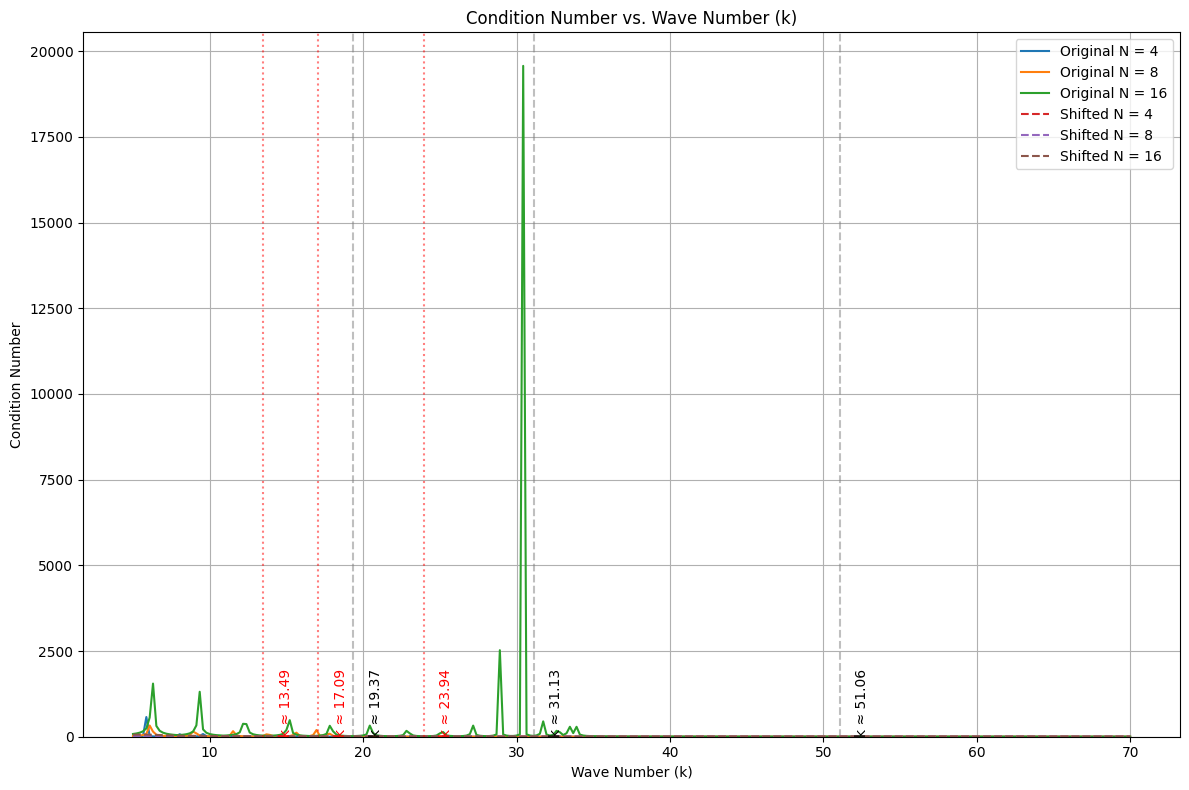

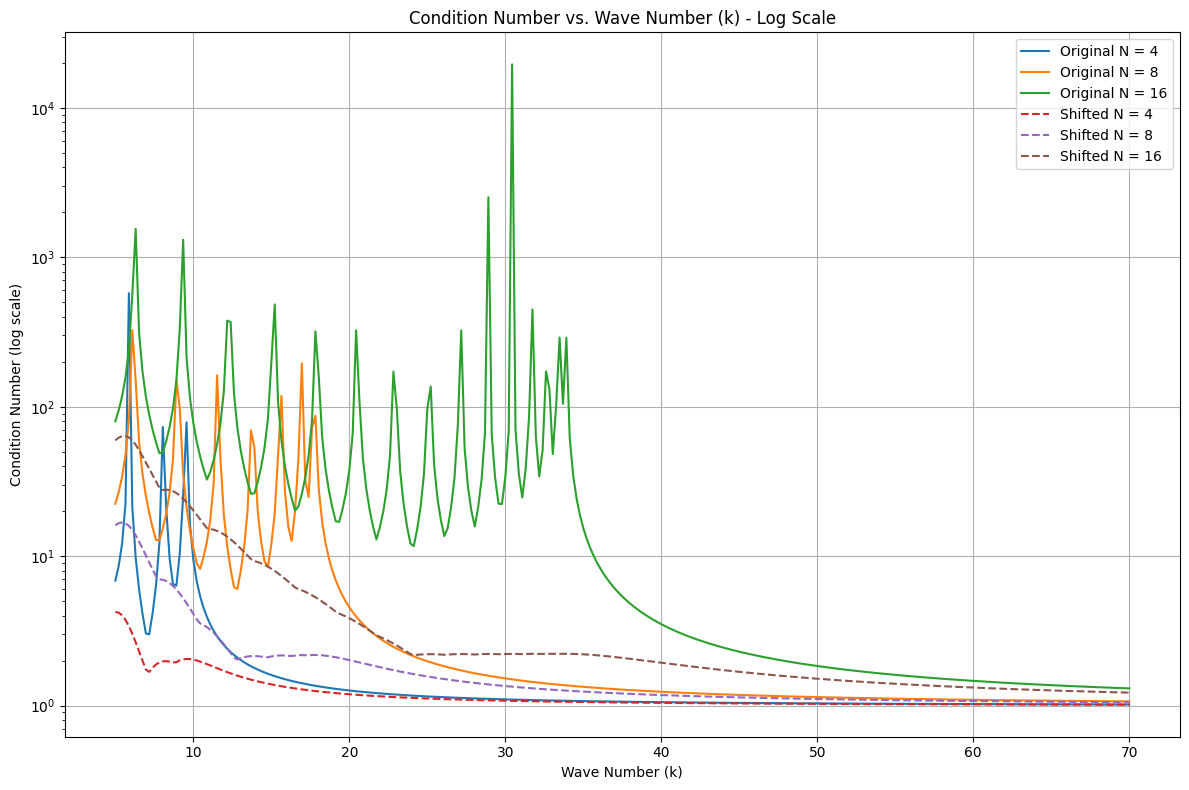

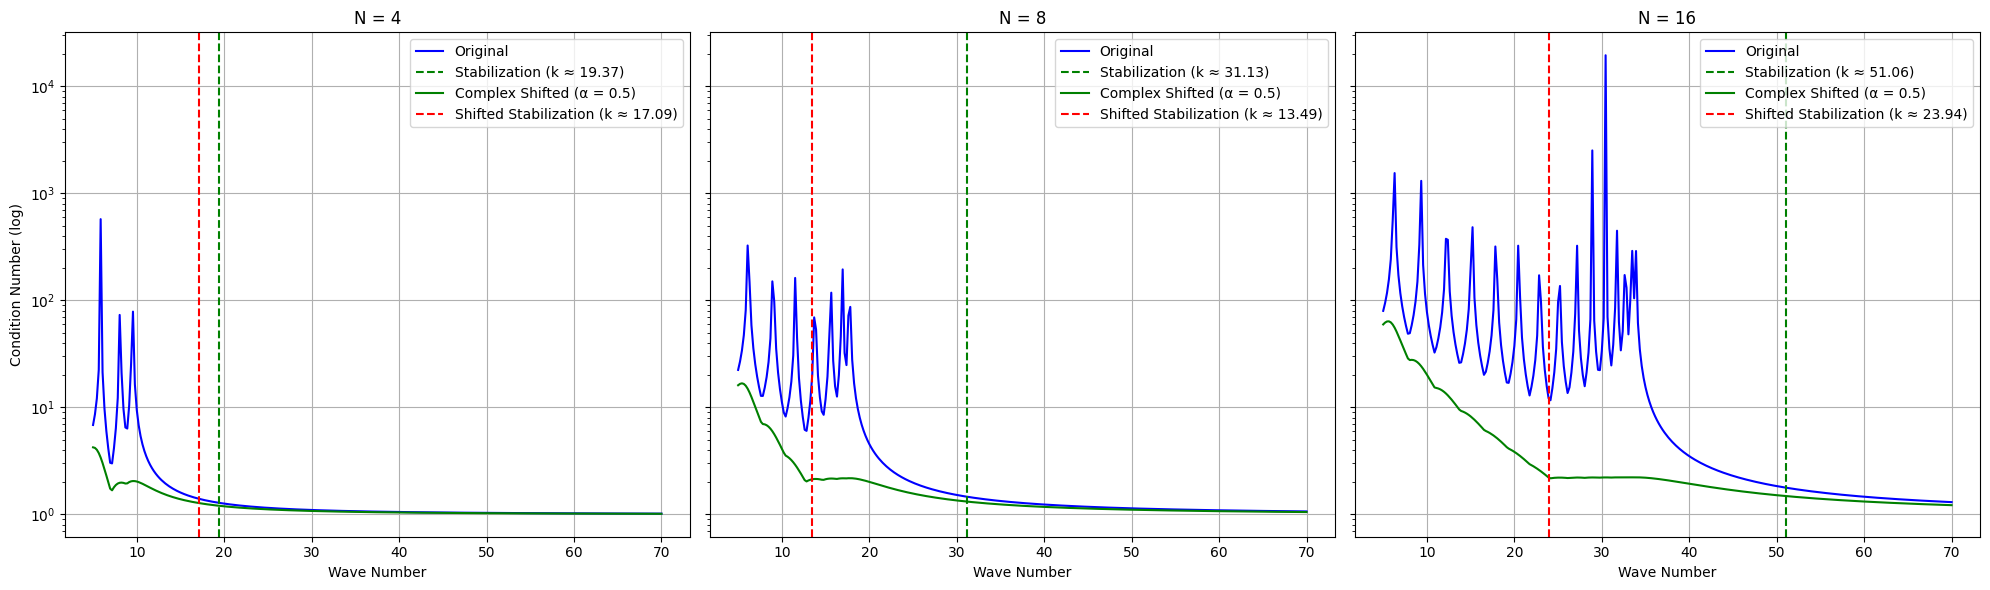

Merged Summary Table with Percentage Difference:
----------------------------------------------------------------------------------------------------
  N | Stabilization k (Original) | Stable Condition Number (Original) | Stabilization k (Shifted) | Stable Condition Number (Shifted) |     % Diff
----------------------------------------------------------------------------------------------------
  4 |                   19.3719 |                         1.2840 |                   17.0854 |                         1.2777 |      -0.50%
  8 |                   31.1307 |                         1.4649 |                   13.4925 |                         2.1322 |     -45.55%
 16 |                   51.0553 |                         1.7780 |                   23.9447 |                         2.2028 |     -23.89%


In [76]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.sparse import diags
import pandas as pd

def compute_matrix_condition_number(k, N, L=1.0, shifted=False, alpha=0.5):
    """Compute condition number using matrix approach like in second code."""
    h = L / (N + 1)
    
    if shifted:
        # Complex shifted Laplacian: -Δ - (1+αi)k²
        a = -2 / h**2 + (1 - 1j * alpha) * k**2
    else:
        # Original Helmholtz operator: -Δ - k²
        a = -2 / h**2 + k**2
        
    b = 1 / h**2
    
    # Create tridiagonal matrix
    M = diags([b, a, b], [-1, 0, 1], shape=(N, N)).toarray()
    
    # Calculate condition number
    cond = np.linalg.cond(M)
    return cond

def find_stabilization_point(N, L=1.0, shifted=False, alpha=0.5, k_range=None, 
                             stability_threshold=0.01, window_size=3):
    """
    Find where the condition number stabilizes (stops changing significantly)
    
    Parameters:
    - N: Dimension
    - L: Domain length
    - shifted: Whether to use complex shifted Laplacian
    - alpha: Complex shift parameter (if shifted=True)
    - k_range: Range of k values to test
    - stability_threshold: Threshold for considering the condition number stable
    - window_size: Number of consecutive points to check for stability
    
    Returns:
    - stabilization_k: k value where condition number stabilizes
    - condition_numbers: Dictionary with k values and condition numbers
    """
    if k_range is None:
        k_range = np.linspace(5, 70, 200)  # Adjusted to match second code range
    
    # Calculate condition numbers for each k in the range
    condition_numbers = {}
    for k in k_range:
        condition_numbers[k] = compute_matrix_condition_number(k, N, L, shifted, alpha)
    
    # Find where the rate of change falls below the threshold
    stabilization_k = None
    
    for i in range(len(k_range) - window_size):
        k_values = k_range[i:i+window_size]
        cond_values = [condition_numbers[k] for k in k_values]
        
        # Calculate percentage changes between consecutive points
        changes = [abs(cond_values[j+1] - cond_values[j])/cond_values[j] for j in range(window_size-1)]
        
        # If all changes in the window are below threshold, consider it stabilized
        if all(change < stability_threshold for change in changes):
            stabilization_k = k_values[0]
            break
    
    return stabilization_k, condition_numbers

# Parameters
ALPHA = 0.5  # Complex shift parameter (typical values are between 0.2 and 0.5)
L = 1.0

# Use N values similar to the original code, but also add the powers of 2 from second code
N_values = [4, 8, 16]
N_values_shifted = [4, 8, 16]  # Comparable to 2^3, 2^4, 2^5 in second code

# Store results for both original and shifted methods
results_original = []
results_shifted = []

# Original system analysis
print("Original Helmholtz Operator Results:")
print("-" * 80)
for N in N_values:
    # Find the stabilization point
    k_range = np.linspace(5, 70, 200)
    stabilization_k, condition_numbers = find_stabilization_point(N, L, shifted=False, k_range=k_range)
    
    # Find condition number at stabilization point
    if stabilization_k is not None:
        stable_cond = condition_numbers[stabilization_k]
    else:
        stable_cond = None
    
    results_original.append({
        'N': N,
        'stabilization_k': stabilization_k,
        'stable_condition_number': stable_cond
    })
    
    print(f"N = {N}:")
    if stabilization_k is not None:
        print(f"  Stabilization occurs at k ≈ {stabilization_k:.4f}")
        print(f"  Condition number at stabilization point: {stable_cond:.4f}")
    else:
        print(f"  No clear stabilization found in the provided k range")
    print()

# Summary table for original system
print("Summary table (Original):")
print("-" * 80)
print(f"{'N':>3} | {'Stabilization k':>15} | {'Stable Condition Number':>25}")
print("-" * 80)
for r in results_original:
    stabilization_k = r['stabilization_k']
    stable_cond = r['stable_condition_number']
    
    if stabilization_k is not None:
        print(f"{r['N']:>3} | {stabilization_k:>15.4f} | {stable_cond:>25.4f}")
    else:
        print(f"{r['N']:>3} | {'Not found':>15} | {'N/A':>25}")
print()

# Complex Shifted system analysis
print("Complex Shifted Laplacian Results:")
print("-" * 80)
for N in N_values_shifted:
    # Find the stabilization point for shifted system
    k_range = np.linspace(5, 70, 200)
    stabilization_k, condition_numbers = find_stabilization_point(N, L, shifted=True, alpha=ALPHA, k_range=k_range)
    
    # Find condition number at stabilization point
    if stabilization_k is not None:
        stable_cond = condition_numbers[stabilization_k]
    else:
        stable_cond = None
    
    results_shifted.append({
        'N': N,
        'stabilization_k': stabilization_k,
        'stable_condition_number': stable_cond
    })
    
    print(f"N = {N} (Shifted, α = {ALPHA}):")
    if stabilization_k is not None:
        print(f"  Stabilization occurs at k ≈ {stabilization_k:.4f}")
        print(f"  Condition number at stabilization point: {stable_cond:.4f}")
    else:
        print(f"  No clear stabilization found in the provided k range")
    print()

# Summary table for shifted system
print("Summary table (Shifted):")
print("-" * 80)
print(f"{'N':>3} | {'Stabilization k':>15} | {'Stable Condition Number':>25}")
print("-" * 80)
for r in results_shifted:
    stabilization_k = r['stabilization_k']
    stable_cond = r['stable_condition_number']
    
    if stabilization_k is not None:
        print(f"{r['N']:>3} | {stabilization_k:>15.4f} | {stable_cond:>25.4f}")
    else:
        print(f"{r['N']:>3} | {'Not found':>15} | {'N/A':>25}")
print()

# Create comparison plots
plt.figure(figsize=(12, 8))

# Plot condition number vs k for original system
for result in results_original:
    N = result['N']
    k_range = np.linspace(5, 70, 300)
    cond_values = [compute_matrix_condition_number(k, N, L, shifted=False) for k in k_range]
    
    # Find the stabilization point
    stabilization_k = result['stabilization_k']
    
    plt.plot(k_range, cond_values, label=f'Original N = {N}')
    
    if stabilization_k is not None:
        plt.axvline(x=stabilization_k, linestyle='--', color='gray', alpha=0.5)
        plt.text(stabilization_k+1, min(cond_values)+1, f'k ≈ {stabilization_k:.2f}', 
                 rotation=90, verticalalignment='bottom')

# Add shifted system for comparison (for smaller N values)
for result in results_shifted:
    N = result['N']
    k_range = np.linspace(5, 70, 300)
    cond_values = [compute_matrix_condition_number(k, N, L, shifted=True, alpha=ALPHA) for k in k_range]
    
    # Find the stabilization point
    stabilization_k = result['stabilization_k']
    
    plt.plot(k_range, cond_values, linestyle='--', label=f'Shifted N = {N}')
    
    if stabilization_k is not None:
        plt.axvline(x=stabilization_k, linestyle=':', color='red', alpha=0.5)
        plt.text(stabilization_k+1, min(cond_values)*1.5, f'k ≈ {stabilization_k:.2f}', 
                 rotation=90, verticalalignment='bottom', color='red')

plt.title('Condition Number vs. Wave Number (k)')
plt.xlabel('Wave Number (k)')
plt.ylabel('Condition Number')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)  # Start y-axis at 0
plt.tight_layout()
plt.savefig('condition_comparison.png')
plt.show()

# Create log-scale plot for better visualization of both systems
plt.figure(figsize=(12, 8))

# Plot condition number vs k for original system (log scale)
for result in results_original:
    N = result['N']
    k_range = np.linspace(5, 70, 300)
    cond_values = [compute_matrix_condition_number(k, N, L, shifted=False) for k in k_range]
    
    plt.plot(k_range, cond_values, label=f'Original N = {N}')

# Add shifted system for comparison
for result in results_shifted:
    N = result['N']
    k_range = np.linspace(5, 70, 300)
    cond_values = [compute_matrix_condition_number(k, N, L, shifted=True, alpha=ALPHA) for k in k_range]
    
    plt.plot(k_range, cond_values, linestyle='--', label=f'Shifted N = {N}')

plt.title('Condition Number vs. Wave Number (k) - Log Scale')
plt.xlabel('Wave Number (k)')
plt.ylabel('Condition Number (log scale)')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('condition_comparison_log.png')
plt.show()

# Create individual plots for each system and dimension
# Original system
fig, axs = plt.subplots(1, len(results_original), figsize=(20, 6), sharey=True)

for ax, (r_orig, r_shift) in zip(axs, zip(results_original, results_shifted)):
    stabilization_k = r_orig['stabilization_k']
    N = r_orig['N']
    k_range = np.linspace(5, 70, 300)
    cond_values = [compute_matrix_condition_number(k, N, L, shifted=False) for k in k_range]   
     
    ax.plot(k_range, cond_values, 'b-', label='Original')
    
    # Mark stabilization point
    if stabilization_k is not None:
        ax.axvline(x=stabilization_k, color='green', linestyle='--', 
                  label=f'Stabilization (k ≈ {stabilization_k:.2f})')
            
    stabilization_k = r_shift['stabilization_k']
    N = r_shift['N']
    cond_values = [compute_matrix_condition_number(k, N, L, shifted=True, alpha=ALPHA) for k in k_range]   
     
    ax.plot(k_range, cond_values, 'g-', label=f'Complex Shifted (α = {ALPHA})')
    
    # Mark stabilization point
    if stabilization_k is not None:
        ax.axvline(x=stabilization_k, color='red', linestyle='--', 
                  label=f'Shifted Stabilization (k ≈ {stabilization_k:.2f})')
    
    ax.set_title(f'N = {N}')
    ax.set_xlabel('Wave Number')
    ax.set_yscale('log')
    ax.grid(True)
    if ax == axs[0]:
        ax.set_ylabel('Condition Number (log)')
    ax.legend()

plt.tight_layout()
plt.savefig('figures/condition_vs_wavenumber_shifted_subplot.png')
plt.show()
    
    
# Shifted system
# Merged summary table with percentage difference
print("Merged Summary Table with Percentage Difference:")
print("-" * 100)
print(f"{'N':>3} | {'Stabilization k (Original)':>25} | {'Stable Condition Number (Original)':>30} | {'Stabilization k (Shifted)':>25} | {'Stable Condition Number (Shifted)':>30} | {'% Diff':>10}")
print("-" * 100)
for r_orig, r_shift in zip(results_original, results_shifted):
    N = r_orig['N']
    stabilization_k_orig = r_orig['stabilization_k']
    stable_cond_orig = r_orig['stable_condition_number']
    stabilization_k_shift = r_shift['stabilization_k']
    stable_cond_shift = r_shift['stable_condition_number']
    
    if stabilization_k_orig is not None and stable_cond_orig is not None and stabilization_k_shift is not None and stable_cond_shift is not None:
        pct_diff = -(abs(stable_cond_shift - stable_cond_orig) / stable_cond_orig) * 100
        print(f"{N:>3} | {stabilization_k_orig:>25.4f} | {stable_cond_orig:>30.4f} | {stabilization_k_shift:>25.4f} | {stable_cond_shift:>30.4f} | {pct_diff:>10.2f}%")
    else:
        print(f"{N:>3} | {'Not found':>25} | {'N/A':>30} | {'Not found':>25} | {'N/A':>30} | {'N/A':>10}")
        
        


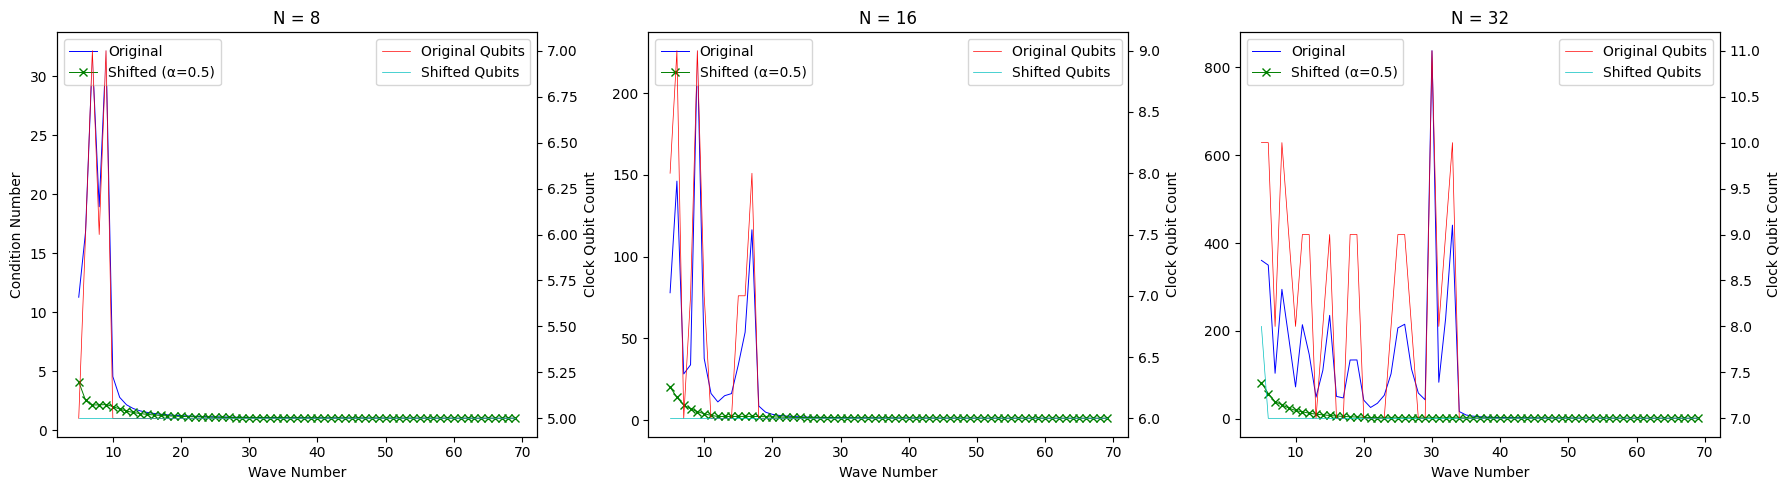

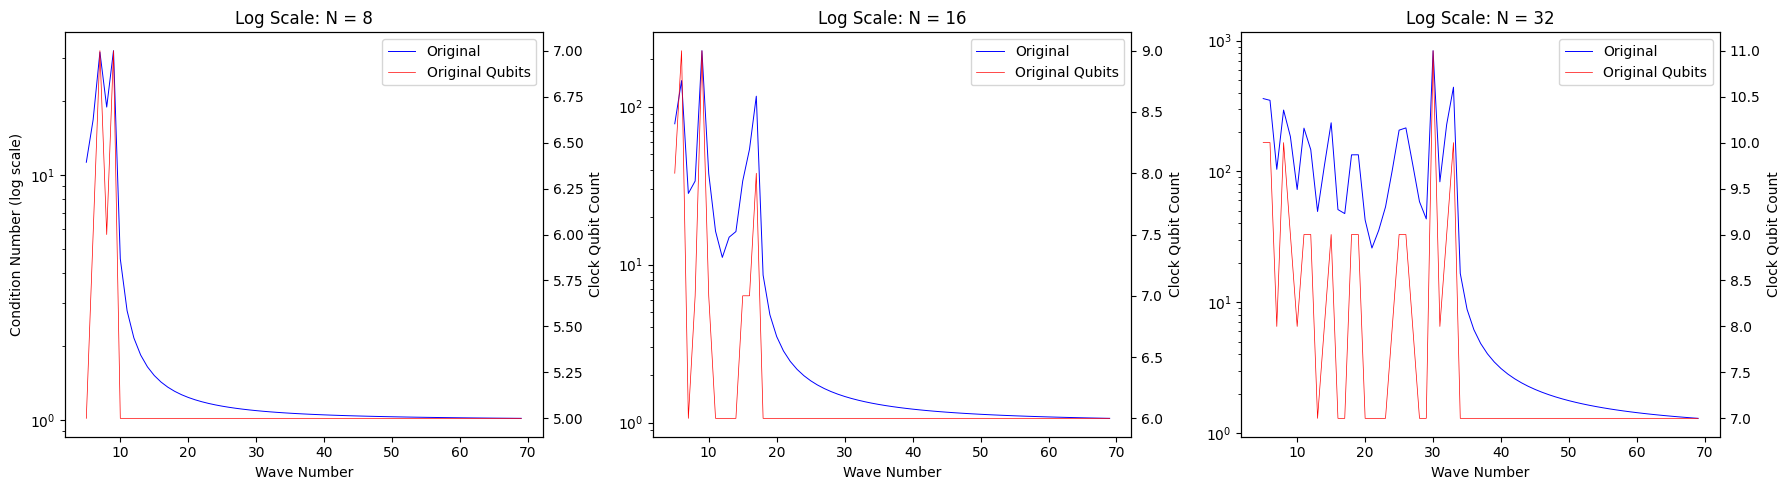

In [77]:


ALPHA = 0.5  # Complex shift parameter (typical values are between 0.2 and 0.5)
NUM_QUBITS_LIST = [3, 4, 5]
k_vals = list(range(5, 70))

# Dictionary to store computed data for each qubit count
results = {}

for num_qubits in NUM_QUBITS_LIST:
    MATRIX_SIZE = 2 ** num_qubits
    L = 2.0
    N = MATRIX_SIZE
    h = L / (N + 1)

    cond_original = []
    cond_shifted = []
    cond_precond = []
    clock_qubits_original = []
    clock_qubits_shifted = []

    nb = num_qubits  # Base number of qubits for the b-vector
    neg_vals = 1

    for kk in k_vals:
        # Original Helmholtz operator: -Δ - k²
        a_orig = -2 / h**2 + kk**2
        b_orig = 1 / h**2
        M_orig = diags([b_orig, a_orig, b_orig], [-1, 0, 1], shape=(N, N)).toarray()

        # Complex shifted Laplacian: -Δ - (1+αi)k²
        a_shifted = -2 / h**2 + (1 - 1j * ALPHA) * kk**2
        b_shifted = 1 / h**2
        M_shifted = diags([b_shifted, a_shifted, b_shifted], [-1, 0, 1], shape=(N, N)).toarray()

        # Compute condition numbers
        c_orig = np.linalg.cond(M_orig)
        cond_original.append(c_orig)

        c_shifted = np.linalg.cond(M_shifted)
        cond_shifted.append(c_shifted)

        # Jacobi Preconditioner for the shifted system
        diag_elements = np.diag(M_shifted)
        D_inv = np.diag(1.0 / diag_elements)
        prec_matrix = D_inv @ M_shifted
        c_prec = np.linalg.cond(prec_matrix)
        cond_precond.append(c_prec)

        # Estimate clock qubits needed for both systems
        n_l_orig = max(nb + 1, int(np.ceil(np.log2(c_orig + 1)))) + neg_vals
        clock_qubits_original.append(n_l_orig)

        n_l_shifted = max(nb + 1, int(np.ceil(np.log2(c_shifted + 1)))) + neg_vals
        clock_qubits_shifted.append(n_l_shifted)

    # Save computed data for this number of qubits
    results[num_qubits] = {
        'N': N,
        'cond_original': cond_original,
        'cond_shifted': cond_shifted,
        'cond_precond': cond_precond,
        'clock_qubits_original': clock_qubits_original,
        'clock_qubits_shifted': clock_qubits_shifted
    }

# Plot condition numbers and clock qubits for each system
fig, axs = plt.subplots(1, len(NUM_QUBITS_LIST), figsize=(18, 5))
for idx, num_qubits in enumerate(NUM_QUBITS_LIST):
    res = results[num_qubits]
    ax1 = axs[idx]
    ax1.plot(k_vals, res['cond_original'], 'b-', linewidth=0.7, label='Original')
    ax1.plot(k_vals, res['cond_shifted'], 'gx-', linewidth=0.7, label=f'Shifted (α={ALPHA})')
    #ax1.plot(k_vals, res['cond_precond'], 'm-', linewidth=0.7, label='Precond. Shifted')
    ax1.set_xlabel('Wave Number')
    ax1.set_title(f'N = {res["N"]}')
    if idx == 0:
        ax1.set_ylabel('Condition Number')

    ax2 = ax1.twinx()
    ax2.plot(k_vals, res['clock_qubits_original'], 'r-', linewidth=0.5, label='Original Qubits')
    ax2.plot(k_vals, res['clock_qubits_shifted'], 'c-', linewidth=0.5, label='Shifted Qubits')
    ax2.set_ylabel('Clock Qubit Count')

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1, labels1, loc='upper left')
    ax2.legend(lines2, labels2, loc='upper right')

plt.tight_layout()
#plt.suptitle(f'Complex Shifted Laplacian with α = {ALPHA}', y=1.05)
plt.savefig('figures/precondition_numbers.png')
plt.show()

# Plot log-scale condition numbers for each system
fig, axs = plt.subplots(1, len(NUM_QUBITS_LIST), figsize=(18, 5))
for idx, num_qubits in enumerate(NUM_QUBITS_LIST):
    res = results[num_qubits]
    ax1 = axs[idx]
    ax1.plot(k_vals, res['cond_original'], 'b-', linewidth=0.7, label='Original')
    #ax1.plot(k_vals, res['cond_shifted'], 'gx-', linewidth=0.7, label=f'Shifted (α={ALPHA})')
    #ax1.plot(k_vals, res['cond_precond'], 'm-', linewidth=0.7, label='Precond. Shifted')
    ax1.set_yscale('log')
    ax1.set_xlabel('Wave Number')
    ax1.set_title(f'Log Scale: N = {res["N"]}')
    if idx == 0:
        ax1.set_ylabel('Condition Number (log scale)')
    
    ax2 = ax1.twinx()
    ax2.plot(k_vals, res['clock_qubits_original'], 'r-', linewidth=0.5, label='Original Qubits')
    #ax2.plot(k_vals, res['clock_qubits_shifted'], 'c-', linewidth=0.5, label='Shifted Qubits')
    ax2.set_ylabel('Clock Qubit Count')

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
#plt.suptitle(f'Log Scale: Complex Shifted Laplacian with α = {ALPHA}', y=1.05)
plt.savefig('figures/precondition_numbers_log.png')
plt.show()


### Testing Cell to Evlauate the impact of preconditioning the matrix

Testing with wave number k = 12.0
Original matrix condition number: 2.1630845668477043
Complex-shifted Laplacian condition number: 2.020404094715654
Updated trotter steps to 645
Updated trotter steps to 13


C:\Users\richa\AppData\Local\Temp\ipykernel_26928\767373434.py:33: DeprecationWarning: The class ``qiskit.utils.quantum_instance.QuantumInstance`` is deprecated as of qiskit-terra 0.24.0. It will be removed in the Qiskit 1.0 release. For code migration guidelines, visit https://qisk.it/qi_migration.
  quantum_instance = QuantumInstance(backend, optimization_level=4, shots=1000)



 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  5

 Number of b qubits 
:  3
Updated trotter steps to 1
Updated trotter steps to 2

 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  5

 Number of b qubits 
:  3
Wave number k = 12.0 Complex shift parameter α = 0.2
shifted qubit count = 11 unshifted qubit count = 11
HHL (Unpreconditioned) MAE: 0.20157752711454202
HHL (Complex-Shifted Preconditioned) MAE: 0.20508785432944934
Thomas Solver MAE: 0.20155581747638507


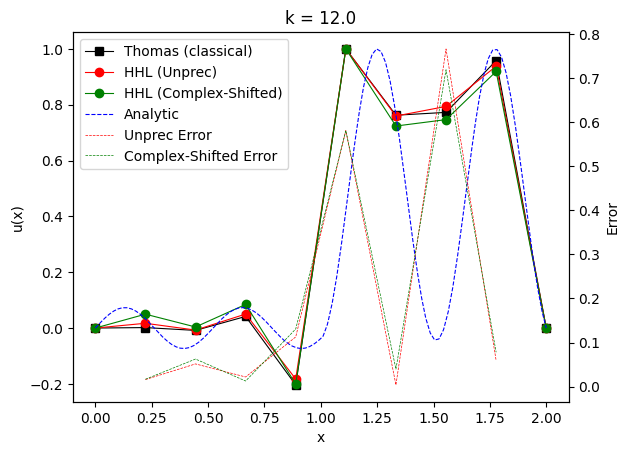

Testing with wave number k = 10.0
Original matrix condition number: 4.549739247933646
Complex-shifted Laplacian condition number: 3.396309465121462
Updated trotter steps to 645
Updated trotter steps to 23


C:\Users\richa\AppData\Local\Temp\ipykernel_26928\767373434.py:33: DeprecationWarning: The class ``qiskit.utils.quantum_instance.QuantumInstance`` is deprecated as of qiskit-terra 0.24.0. It will be removed in the Qiskit 1.0 release. For code migration guidelines, visit https://qisk.it/qi_migration.
  quantum_instance = QuantumInstance(backend, optimization_level=4, shots=1000)



 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  5

 Number of b qubits 
:  3
Updated trotter steps to 1
Updated trotter steps to 8

 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  5

 Number of b qubits 
:  3
Wave number k = 10.0 Complex shift parameter α = 0.2
shifted qubit count = 11 unshifted qubit count = 11
HHL (Unpreconditioned) MAE: 0.36913576318683167
HHL (Complex-Shifted Preconditioned) MAE: 0.3339576488332574
Thomas Solver MAE: 0.36510250675052863


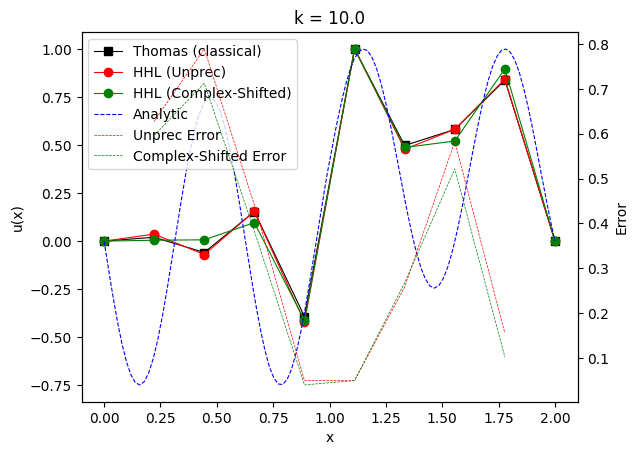

Testing with wave number k = 8.0
Original matrix condition number: 18.94078496671671
Complex-shifted Laplacian condition number: 4.760981653275702
Updated trotter steps to 645
Updated trotter steps to 27


C:\Users\richa\AppData\Local\Temp\ipykernel_26928\767373434.py:33: DeprecationWarning: The class ``qiskit.utils.quantum_instance.QuantumInstance`` is deprecated as of qiskit-terra 0.24.0. It will be removed in the Qiskit 1.0 release. For code migration guidelines, visit https://qisk.it/qi_migration.
  quantum_instance = QuantumInstance(backend, optimization_level=4, shots=1000)



 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  6

 Number of b qubits 
:  3
Updated trotter steps to 1
Updated trotter steps to 23

 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  5

 Number of b qubits 
:  3
Wave number k = 8.0 Complex shift parameter α = 0.2
shifted qubit count = 11 unshifted qubit count = 12
HHL (Unpreconditioned) MAE: 0.8056467092858417
HHL (Complex-Shifted Preconditioned) MAE: 0.5167957920389694
Thomas Solver MAE: 0.8051235346315413


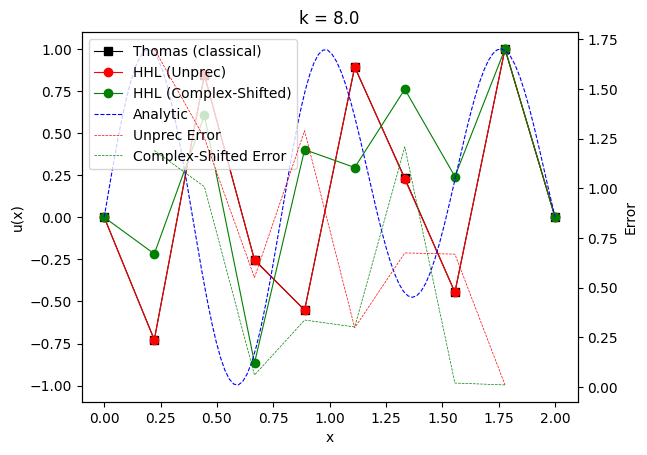

Testing with wave number k = 6.0
Original matrix condition number: 16.802894503519692
Complex-shifted Laplacian condition number: 5.655079740602456
Updated trotter steps to 645
Updated trotter steps to 39


C:\Users\richa\AppData\Local\Temp\ipykernel_26928\767373434.py:33: DeprecationWarning: The class ``qiskit.utils.quantum_instance.QuantumInstance`` is deprecated as of qiskit-terra 0.24.0. It will be removed in the Qiskit 1.0 release. For code migration guidelines, visit https://qisk.it/qi_migration.
  quantum_instance = QuantumInstance(backend, optimization_level=4, shots=1000)



 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  6

 Number of b qubits 
:  3
Updated trotter steps to 1
Updated trotter steps to 2

 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  5

 Number of b qubits 
:  3
Wave number k = 6.0 Complex shift parameter α = 0.2
shifted qubit count = 11 unshifted qubit count = 12
HHL (Unpreconditioned) MAE: 0.18763088909852876
HHL (Complex-Shifted Preconditioned) MAE: 0.08394386955068331
Thomas Solver MAE: 0.18720481753122425


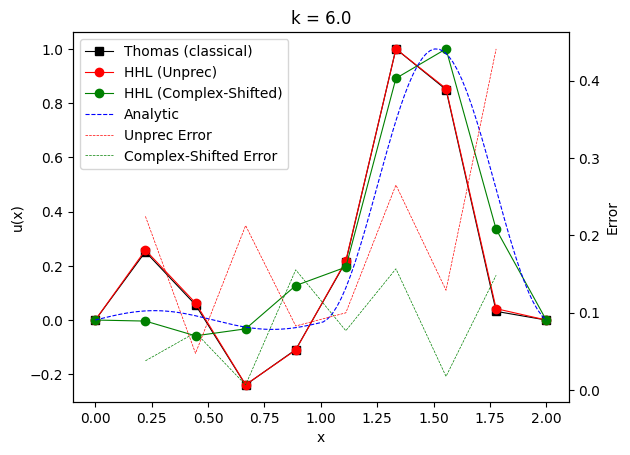

Testing with wave number k = 4.0
Original matrix condition number: 14.719423798077477
Complex-shifted Laplacian condition number: 11.774291663182447
Updated trotter steps to 645
Updated trotter steps to 50


C:\Users\richa\AppData\Local\Temp\ipykernel_26928\767373434.py:33: DeprecationWarning: The class ``qiskit.utils.quantum_instance.QuantumInstance`` is deprecated as of qiskit-terra 0.24.0. It will be removed in the Qiskit 1.0 release. For code migration guidelines, visit https://qisk.it/qi_migration.
  quantum_instance = QuantumInstance(backend, optimization_level=4, shots=1000)



 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  5

 Number of b qubits 
:  3
Updated trotter steps to 1
Updated trotter steps to 4

 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  5

 Number of b qubits 
:  3
Wave number k = 4.0 Complex shift parameter α = 0.2
shifted qubit count = 11 unshifted qubit count = 11
HHL (Unpreconditioned) MAE: 0.09562352779689337
HHL (Complex-Shifted Preconditioned) MAE: 0.06606522599066733
Thomas Solver MAE: 0.07202135044114966


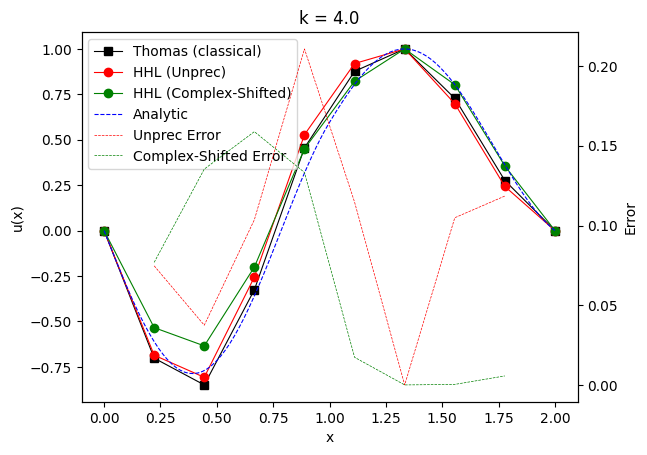

Testing with wave number k = 2.0
Original matrix condition number: 47.868444983619824
Complex-shifted Laplacian condition number: 42.58268072355506
Updated trotter steps to 645
Updated trotter steps to 28


C:\Users\richa\AppData\Local\Temp\ipykernel_26928\767373434.py:33: DeprecationWarning: The class ``qiskit.utils.quantum_instance.QuantumInstance`` is deprecated as of qiskit-terra 0.24.0. It will be removed in the Qiskit 1.0 release. For code migration guidelines, visit https://qisk.it/qi_migration.
  quantum_instance = QuantumInstance(backend, optimization_level=4, shots=1000)



 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  7

 Number of b qubits 
:  3
Updated trotter steps to 1
Updated trotter steps to 2

 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  5

 Number of b qubits 
:  3
Wave number k = 2.0 Complex shift parameter α = 0.2
shifted qubit count = 11 unshifted qubit count = 13
HHL (Unpreconditioned) MAE: 0.011635985716925827
HHL (Complex-Shifted Preconditioned) MAE: 0.042171395678289675
Thomas Solver MAE: 0.016912197989716653


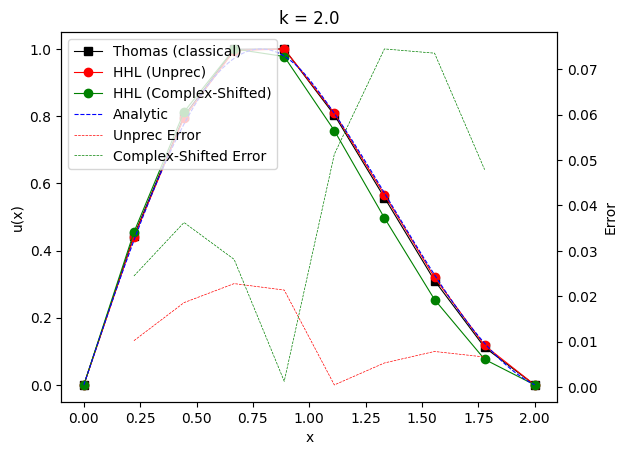

Testing with wave number k = 1.0
Original matrix condition number: 53.76797291807363
Complex-shifted Laplacian condition number: 53.25864852882338
Updated trotter steps to 645
Updated trotter steps to 32


C:\Users\richa\AppData\Local\Temp\ipykernel_26928\767373434.py:33: DeprecationWarning: The class ``qiskit.utils.quantum_instance.QuantumInstance`` is deprecated as of qiskit-terra 0.24.0. It will be removed in the Qiskit 1.0 release. For code migration guidelines, visit https://qisk.it/qi_migration.
  quantum_instance = QuantumInstance(backend, optimization_level=4, shots=1000)



 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  7

 Number of b qubits 
:  3
Updated trotter steps to 1
Updated trotter steps to 1

 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  5

 Number of b qubits 
:  3
Wave number k = 1.0 Complex shift parameter α = 0.2
shifted qubit count = 11 unshifted qubit count = 13
HHL (Unpreconditioned) MAE: 0.0036805271802968255
HHL (Complex-Shifted Preconditioned) MAE: 0.006373528863358763
Thomas Solver MAE: 0.004342920428198057


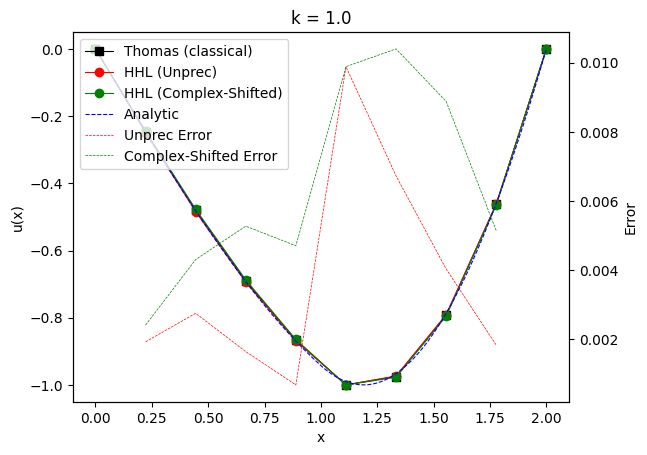

In [90]:
def solve_helmholtz(NUM_QUBITS, L, k, eps, alpha):
    MATRIX_SIZE = 2 ** NUM_QUBITS
    N = MATRIX_SIZE
    h = L / (N + 1)
    
    x_numerical = np.linspace(0, L, N + 2)[1:-1]  # 8 interior points
    x_fine = np.linspace(0, L, 1000)              # 1000 points for smooth plotting

    # 2) Build the Helmholtz matrix and RHS vector
    a = -2 / h**2 + k**2
    b = 1 / h**2
    matrix = diags([b, a, b], [-1, 0, 1], shape=(MATRIX_SIZE, MATRIX_SIZE)).toarray()
    vector = np.where(x_numerical < L / 2, 0.0, L)

    # 3) Build the complex-shifted Laplacian preconditioner
    a_shifted = -2 / h**2 + k**2 * (1 - 1j * alpha)
    b_shifted = 1 / h**2
    a_real = np.real(a_shifted)
    a_imag = np.imag(a_shifted)
    b_real = np.real(b_shifted)
    P_real = diags([b_real, a_real, b_real], [-1, 0, 1], shape=(MATRIX_SIZE, MATRIX_SIZE)).toarray()
    P_imag = diags([0, a_imag, 0], [-1, 0, 1], shape=(MATRIX_SIZE, MATRIX_SIZE)).toarray()
    P_complex = P_real + 1j * P_imag

    print("Original matrix condition number:", np.linalg.cond(matrix))
    print("Complex-shifted Laplacian condition number:", np.linalg.cond(P_complex))

    # 4) Create the unpreconditioned TridiagonalToeplitz object
    tridi_mat = TridiagonalToeplitz(NUM_QUBITS, a, b)

    # 5) Set up quantum instance
    backend = Aer.get_backend('qasm_simulator')
    quantum_instance = QuantumInstance(backend, optimization_level=4, shots=1000)

    # 6) Solve unpreconditioned system with HHL
    tridi_hhl = HHL(epsilon=eps, quantum_instance=quantum_instance)
    solution_unprec = tridi_hhl.solve(tridi_mat, vector)
    hhl_vector_unprec = get_solution_vector(solution_unprec, solution_unprec.state.num_qubits, vector)
    hhl_vector_unprec = np.concatenate(([0], hhl_vector_unprec, [0]))
    hhl_vector_unprec = normalize(hhl_vector_unprec, -1, 1)

    # 7) Classical preconditioning
    P_inv = np.linalg.inv(P_complex)
    prec_matrix_complex = P_inv @ matrix
    prec_vector_complex = P_inv @ vector
    prec_matrix = np.real(prec_matrix_complex)
    prec_vector = np.real(prec_vector_complex)

    # 8) Approximate preconditioned matrix as TridiagonalToeplitz
    a_prec = np.mean(np.diag(prec_matrix))
    b_prec = np.mean(np.diag(prec_matrix, 1))
    tridi_mat_precond = TridiagonalToeplitz(NUM_QUBITS, a_prec, b_prec)

    # 9) Solve preconditioned system with HHL
    solution_prec = tridi_hhl.solve(tridi_mat_precond, prec_vector)
    hhl_vector_prec = get_solution_vector(solution_prec, solution_prec.state.num_qubits, prec_vector)
    hhl_vector_prec = np.concatenate(([0], hhl_vector_prec, [0]))
    hhl_vector_prec = normalize(hhl_vector_prec, -1, 1)

    # 10) Classical Thomas solver
    thomas = numerical_solvers()
    num_solution = thomas.solve_tridiagonal_thomas(matrix, vector)
    num_solution = np.concatenate(([0], num_solution, [0]))
    num_solution = normalize(num_solution, -1, 1)

    # 11) High-resolution Thomas solver for pseudo-analytic solution
    N_high_res = 100
    h_high_res = L / (N_high_res + 1)
    x_interior_high_res = np.linspace(0, L, N_high_res + 2)[1:-1]
    a_high_res = -2 / h_high_res**2 + k**2
    b_high_res = 1 / h_high_res**2
    matrix_high_res = diags([b_high_res, a_high_res, b_high_res], [-1, 0, 1], shape=(N_high_res, N_high_res)).toarray()
    f_high_res = np.where(x_interior_high_res < L / 2, 0.0, 1.0)
    hi_thomas_interior = thomas.solve_tridiagonal_thomas(matrix_high_res, f_high_res)
    hi_thomas_vector = np.concatenate(([0], hi_thomas_interior, [0]))
    hi_thomas_sol = normalize(hi_thomas_vector, -1, 1)
    hi_real_domain = np.linspace(0, L, N_high_res + 2)

    # Compute errors
    u_interp = np.interp(x_numerical, hi_real_domain, hi_thomas_sol)
    mae_unprec = np.mean(np.abs(hhl_vector_unprec[1:-1] - u_interp))
    mae_prec = np.mean(np.abs(hhl_vector_prec[1:-1] - u_interp))
    mae_thomas = np.mean(np.abs(num_solution[1:-1] - u_interp))

    print(f"Wave number k = {k} Complex shift parameter α = {alpha}")
    print(f"shifted qubit count = {solution_prec.state.num_qubits} unshifted qubit count = {solution_unprec.state.num_qubits}")
    print(f"HHL (Unpreconditioned) MAE: {mae_unprec}")
    print(f"HHL (Complex-Shifted Preconditioned) MAE: {mae_prec}")
    print(f"Thomas Solver MAE: {mae_thomas}")

    # 12) Plot results
    fig, ax1 = plt.subplots()
    real_domain = np.concatenate(([0], x_numerical, [L]))

    ax1.plot(real_domain, num_solution, 'ks-', linewidth=0.8, label='Thomas (classical)')
    ax1.plot(real_domain, hhl_vector_unprec, 'ro-', linewidth=0.8, label='HHL (Unprec)')
    ax1.plot(real_domain, hhl_vector_prec, 'go-', linewidth=0.8, label='HHL (Complex-Shifted)')
    u_analytic_fine = np.interp(x_fine, hi_real_domain, hi_thomas_sol)
    ax1.plot(x_fine, u_analytic_fine, 'b--', linewidth=0.8, label='Analytic')

    ax1.set_xlabel('x')
    ax1.set_ylabel('u(x)')
    ax1.set_title(f'k = {k}')
    
    # Error plot on twin axis
    ax2 = ax1.twinx()
    hhl_error_unprec = np.abs(hhl_vector_unprec[1:-1] - u_interp)
    hhl_error_prec = np.abs(hhl_vector_prec[1:-1] - u_interp)
    ax2.plot(x_numerical, hhl_error_unprec, 'r--', linewidth=0.5, label='Unprec Error')
    ax2.plot(x_numerical, hhl_error_prec, 'g--', linewidth=0.5, label='Complex-Shifted Error')
    ax2.set_ylabel('Error')

    # Combine legends
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='upper left')
    plt.savefig(f'figures/helmholtz_hhl_preconditioning{k}.png')

    plt.show()

# Test the function with different wave numbers
wave_numbers = [1.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0]
wave_numbers = wave_numbers[::-1]
for k in wave_numbers:
    print(f"Testing with wave number k = {k}")
    solve_helmholtz(NUM_QUBITS=3, L=2.0, k=k, eps=0.001, alpha=0.2)

### Preconditioners and Wave Numbers Optimization Study

In [17]:
import matplotlib.cm as cm

# Parameter study setup
NUM_QUBITS = 3
MATRIX_SIZE = 2 ** NUM_QUBITS
L = 2.0
N = MATRIX_SIZE
h = L / (N+1)
eps = 0.01  # HHL error tolerance

# Parameter ranges for study
alpha_values = np.linspace(0.1, 0.9, 9)   # Complex shift parameter values
kappa_values = [i for i in range(5, 20, 2)]    # Wave number values
# Initialize results matrices for HHL and Thomas
mae_hhl_unprec_matrix = np.zeros((len(alpha_values), len(kappa_values)))
mae_hhl_prec_matrix = np.zeros((len(alpha_values), len(kappa_values)))
mae_thomas_unprec_matrix = np.zeros((len(alpha_values), len(kappa_values)))
cond_orig_matrix = np.zeros((len(alpha_values), len(kappa_values)))
orig_qubit_counts = np.zeros((len(alpha_values), len(kappa_values)))
prec_qubit_counts = np.zeros((len(alpha_values), len(kappa_values)))
cond_shifted_matrix = np.zeros((len(alpha_values), len(kappa_values)))

# Create grids for interior points
x_numerical = np.linspace(0, L, N+2)[1:-1]  # Interior points
x_fine = np.linspace(0, L, 1000)            # Fine grid for analytic

# Setup solvers
thomas = numerical_solvers()
backend = Aer.get_backend('qasm_simulator')
quantum_instance = QuantumInstance(backend, optimization_level=4, shots=1000)
tridi_hhl = HHL(epsilon=eps, quantum_instance=quantum_instance)
    
# Perform parameter sweep
for i, alpha in enumerate(alpha_values):
    for j, k in enumerate(kappa_values):
        # Original matrix and vector
        a = -2/h**2 + k**2
        b = 1/h**2
        matrix = diags([b, a, b], [-1, 0, 1], shape=(MATRIX_SIZE, MATRIX_SIZE)).toarray()
         # Interior grid points (excluding boundaries)
        vector = np.where(x_numerical < L/2, 0.0, L)

        cond_orig_matrix[i, j] = np.linalg.cond(matrix)

        # Preconditioner (complex-shifted)
        a_shifted = -2/h**2 + k**2 * (1 - 1j * alpha)
        b_shifted = 1/h**2
        P_complex = diags([b_shifted, a_shifted, b_shifted], [-1, 0, 1], shape=(MATRIX_SIZE, MATRIX_SIZE)).toarray()
        cond_shifted_matrix[i, j] = np.linalg.cond(P_complex)

        # Compute preconditioned system
        P_inv = np.linalg.inv(P_complex)
        prec_matrix_complex = P_inv @ matrix
        prec_vector_complex = P_inv @ vector
        prec_matrix = np.real(prec_matrix_complex)
        prec_vector = np.real(prec_vector_complex)

        # HHL for unpreconditioned
        tridi_mat_hhl_unprec = TridiagonalToeplitz(NUM_QUBITS, a, b)
        solution_hhl_unprec = tridi_hhl.solve(tridi_mat_hhl_unprec, vector)
        orig_qubit_counts[i, j] = solution_hhl_unprec.state.num_qubits
        hhl_solution_unprec = get_solution_vector(solution_hhl_unprec, solution_hhl_unprec.state.num_qubits, vector)
        hhl_solution_unprec = np.concatenate(([0], hhl_solution_unprec, [0]))
        hhl_solution_unprec = normalize(hhl_solution_unprec, -1, 1)
        mae_hhl_unprec = np.mean(np.abs(hhl_solution_unprec[1:-1] - np.sin(np.pi * x_numerical)))
        mae_hhl_unprec_matrix[i, j] = mae_hhl_unprec

        # HHL for preconditioned
        a_prec = np.mean(np.diag(prec_matrix))
        b_prec = np.mean(np.diag(prec_matrix, 1))
        tridi_mat_hhl_prec = TridiagonalToeplitz(NUM_QUBITS, a_prec, b_prec)
        solution_hhl_prec = tridi_hhl.solve(tridi_mat_hhl_prec, prec_vector)
        prec_qubit_counts[i, j] = solution_hhl_prec.state.num_qubits
        hhl_solution_prec = get_solution_vector(solution_hhl_prec, solution_hhl_prec.state.num_qubits, prec_vector)
        hhl_solution_prec = np.concatenate(([0], hhl_solution_prec, [0]))
        hhl_solution_prec = normalize(hhl_solution_prec, -1, 1)
        mae_hhl_prec = np.mean(np.abs(hhl_solution_prec[1:-1] - np.sin(np.pi * x_numerical)))
        mae_hhl_prec_matrix[i, j] = mae_hhl_prec

        # Thomas for unpreconditioned
        num_solution_unprec = thomas.solve_tridiagonal_thomas(matrix, vector)
        num_solution_unprec = np.concatenate(([0], num_solution_unprec, [0]))
        num_solution_unprec = normalize(num_solution_unprec, -1, 1)
        mae_thomas_unprec = np.mean(np.abs(num_solution_unprec[1:-1] - np.sin(np.pi * x_numerical)))
        mae_thomas_unprec_matrix[i, j] = mae_thomas_unprec

        # Print results for each parameter combination
        print('--------------------------------------------')
        print(f"Wave number (κ): {k:.2f} | Complex shift (α): {alpha:.2f}")
        print(f"HHL Unpreconditioned MAE: {mae_hhl_unprec:.6f} | HHL Preconditioned MAE: {mae_hhl_prec:.6f}")
        print(f"Condition number Orig: {cond_orig_matrix[i, j]:.2f} | Condition number Shifted: {cond_shifted_matrix[i, j]:.2f}")
        print(f"Number of qubits Unprec: {solution_hhl_unprec.state.num_qubits} | Number of qubits Prec: {solution_hhl_prec.state.num_qubits}")
        print(f"Thomas Unpreconditioned MAE: {mae_thomas_unprec:.6f} ")
        

C:\Users\richa\AppData\Local\Temp\ipykernel_26928\167655595.py:30: DeprecationWarning: The class ``qiskit.utils.quantum_instance.QuantumInstance`` is deprecated as of qiskit-terra 0.24.0. It will be removed in the Qiskit 1.0 release. For code migration guidelines, visit https://qisk.it/qi_migration.
  quantum_instance = QuantumInstance(backend, optimization_level=4, shots=1000)


Updated trotter steps to 645
Updated trotter steps to 14

 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  5

 Number of b qubits 
:  3
Updated trotter steps to 1
Updated trotter steps to 1

 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  5

 Number of b qubits 
:  3
--------------------------------------------
Wave number (κ): 5.00 | Complex shift (α): 0.10
HHL Unpreconditioned MAE: 0.990268 | HHL Preconditioned MAE: 1.009186
Condition number Orig: 11.28 | Condition number Shifted: 9.99
Number of qubits Unprec: 11 | Number of qubits Prec: 11
Thomas Unpreconditioned MAE: 0.979741 
Updated trotter steps to 645
Updated trotter steps to 10

 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  7

 Number of b qubits 
:  3
Updated trotter steps to 1
Updated trotter steps to 1

 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  5



C:\Users\richa\AppData\Local\Temp\ipykernel_26928\2018213017.py:111: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXS


SUMMARY OF PARAMETER STUDY FINDINGS:
Average HHL MAE without preconditioning: 1.1012072751150295
Average HHL MAE with preconditioning: 1.1275588442663436
Average Thomas MAE without preconditioning: 1.103127208078208
Average HHL improvement ratio: 1.0271388951701326

Optimal α values by wave number κ for HHL:
κ = 5.0: optimal α = 0.10
κ = 7.0: optimal α = 0.20
κ = 9.0: optimal α = 0.60
κ = 11.0: optimal α = 0.20
κ = 13.0: optimal α = 0.70
κ = 15.0: optimal α = 0.20
κ = 17.0: optimal α = 0.60
κ = 19.0: optimal α = 0.80

Global optimal parameter combination for HHL:
α = 0.20, κ = 7.0
Resulting in HHL MAE = 0.929244


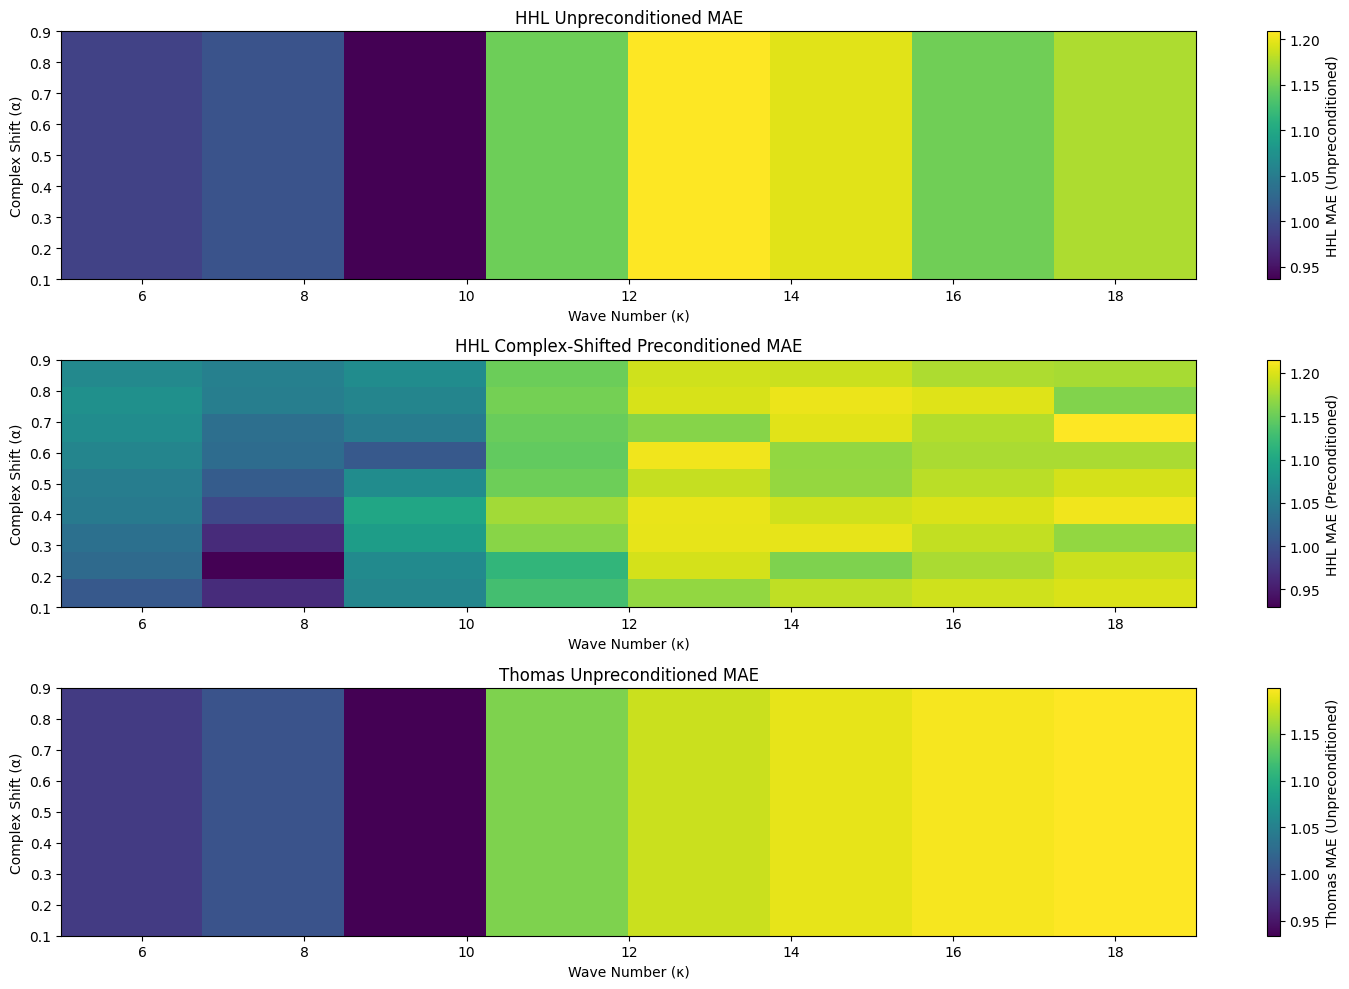

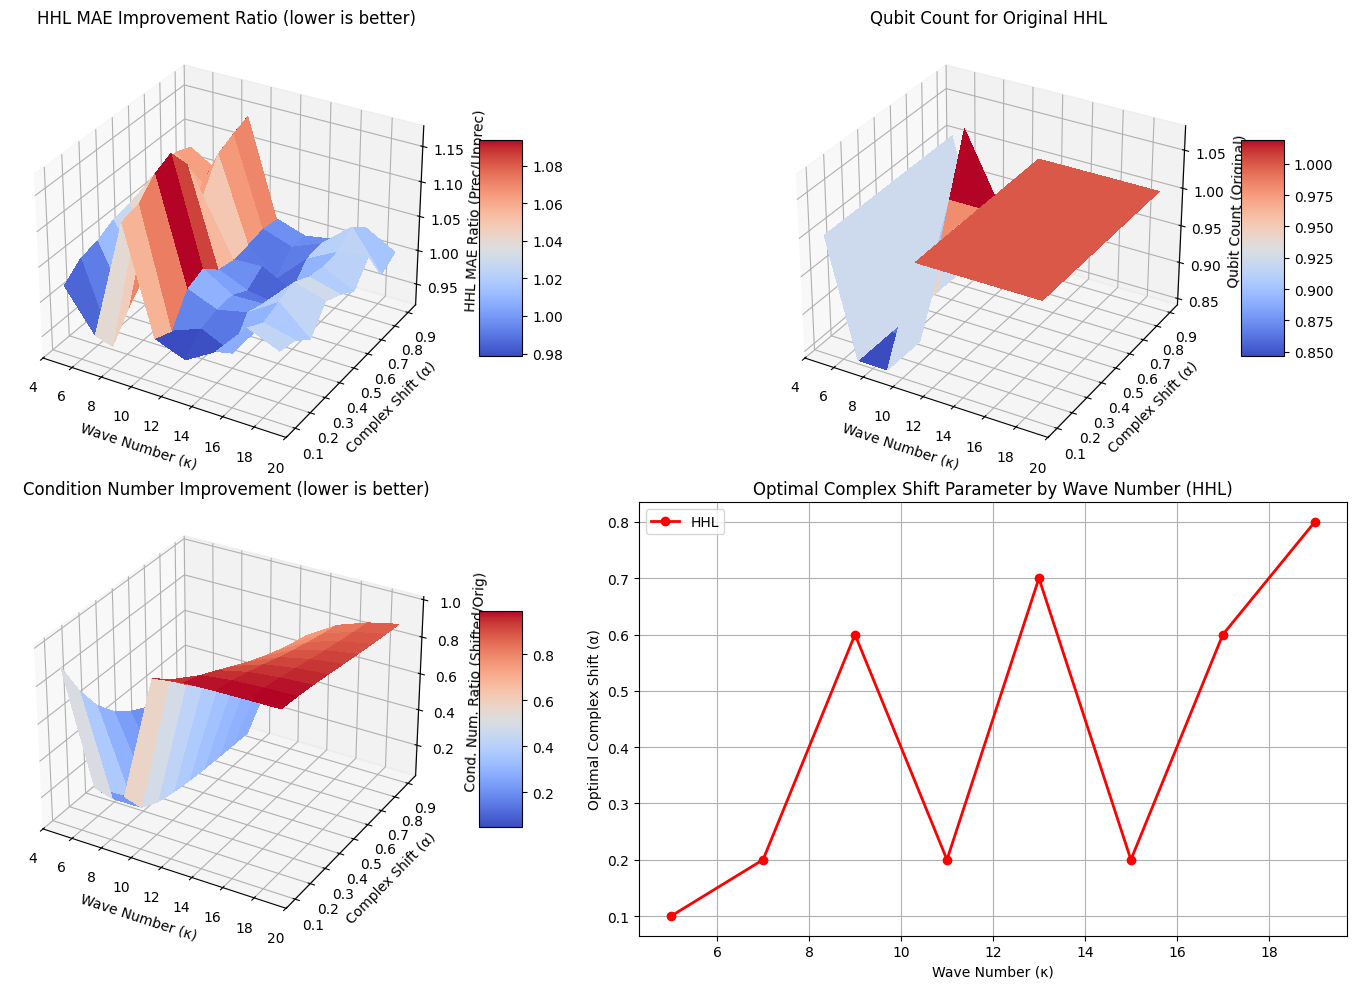

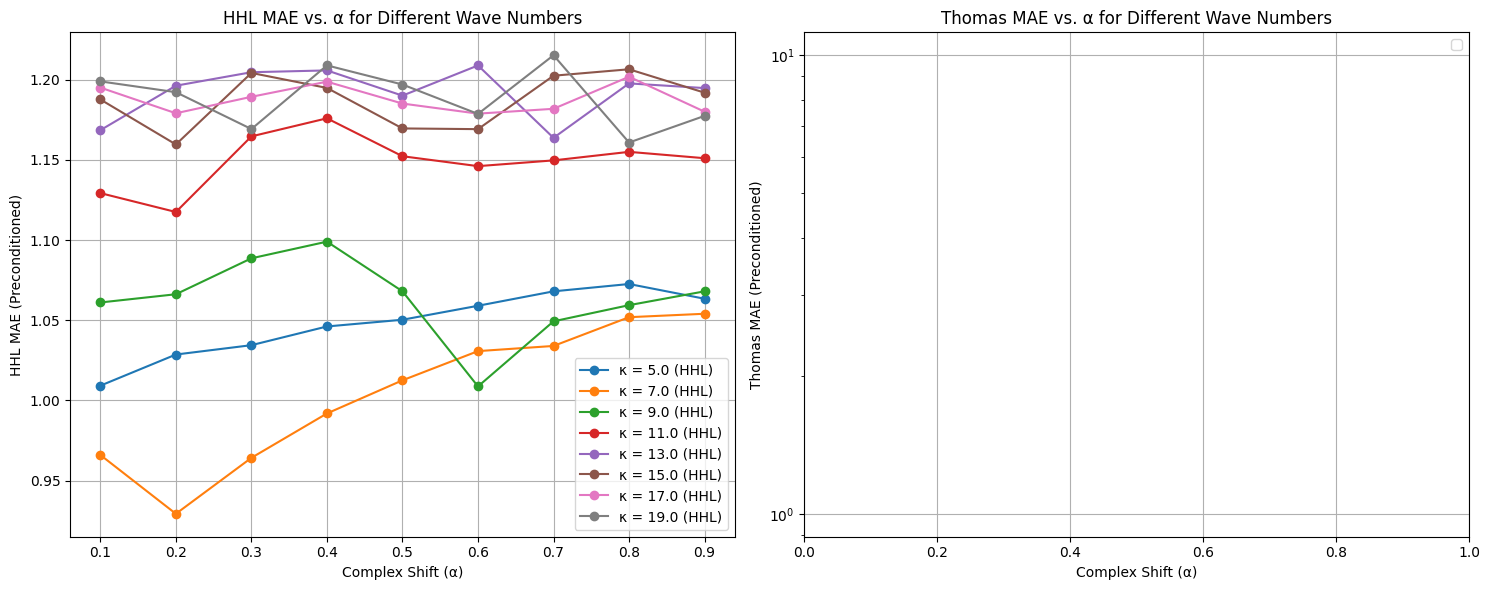

In [18]:

# Plotting the results
fig = plt.figure(figsize=(15, 10))

# Heatmaps for HHL MAE
plt.subplot(311)
plt.imshow(mae_hhl_unprec_matrix, cmap='viridis', origin='lower', aspect='auto',
           extent=[min(kappa_values), max(kappa_values), min(alpha_values), max(alpha_values)])
plt.colorbar(label='HHL MAE (Unpreconditioned)')
plt.xlabel('Wave Number (κ)')
plt.ylabel('Complex Shift (α)')
plt.title('HHL Unpreconditioned MAE')

plt.subplot(312)
plt.imshow(mae_hhl_prec_matrix, cmap='viridis', origin='lower', aspect='auto',
           extent=[min(kappa_values), max(kappa_values), min(alpha_values), max(alpha_values)])
plt.colorbar(label='HHL MAE (Preconditioned)')
plt.xlabel('Wave Number (κ)')
plt.ylabel('Complex Shift (α)')
plt.title('HHL Complex-Shifted Preconditioned MAE')

# Heatmaps for Thomas MAE
plt.subplot(313)
plt.imshow(mae_thomas_unprec_matrix, cmap='viridis', origin='lower', aspect='auto',
           extent=[min(kappa_values), max(kappa_values), min(alpha_values), max(alpha_values)])
plt.colorbar(label='Thomas MAE (Unpreconditioned)')
plt.xlabel('Wave Number (κ)')
plt.ylabel('Complex Shift (α)')
plt.title('Thomas Unpreconditioned MAE')

plt.tight_layout()
plt.savefig('parameter_study_heatmaps.png', dpi=300, bbox_inches='tight')

# 3D surface plots
fig = plt.figure(figsize=(15, 10))

# MAE improvement ratio for HHL
improvement_ratio_hhl = mae_hhl_prec_matrix / mae_hhl_unprec_matrix

ax = fig.add_subplot(221, projection='3d')
X, Y = np.meshgrid(kappa_values, alpha_values)
surf = ax.plot_surface(X, Y, improvement_ratio_hhl, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)
ax.set_xlabel('Wave Number (κ)')
ax.set_ylabel('Complex Shift (α)')
ax.set_zlabel('HHL MAE Ratio (Prec/Unprec)')
ax.set_title('HHL MAE Improvement Ratio (lower is better)')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

# MAE improvement ratio for Thomas

# Condition number ratio
cond_ratio = cond_shifted_matrix / cond_orig_matrix
qubit_ratio = prec_qubit_counts / orig_qubit_counts 
# Plot of qubit count condition number and wave number 3D
ax = fig.add_subplot(222, projection='3d')
surf = ax.plot_surface(X, Y, qubit_ratio, cmap=cm.coolwarm,
                          linewidth=0, antialiased=False)
ax.set_xlabel('Wave Number (κ)')
ax.set_ylabel('Complex Shift (α)')
ax.set_zlabel('Qubit Count (Original)')
ax.set_title('Qubit Count for Original HHL')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)


ax = fig.add_subplot(223, projection='3d')
surf = ax.plot_surface(X, Y, cond_ratio, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)
ax.set_xlabel('Wave Number (κ)')
ax.set_ylabel('Complex Shift (α)')
ax.set_zlabel('Cond. Num. Ratio (Shifted/Orig)')
ax.set_title('Condition Number Improvement (lower is better)')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)


# Optimal alpha for HHL MAE
optimal_alpha_indices_hhl = np.argmin(mae_hhl_prec_matrix, axis=0)
optimal_alpha_values_hhl = alpha_values[optimal_alpha_indices_hhl]

ax = fig.add_subplot(224)
ax.plot(kappa_values, optimal_alpha_values_hhl, 'ro-', linewidth=2, label='HHL')
ax.set_xlabel('Wave Number (κ)')
ax.set_ylabel('Optimal Complex Shift (α)')
ax.set_title('Optimal Complex Shift Parameter by Wave Number (HHL)')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig('parameter_study_3d.png', dpi=300, bbox_inches='tight')

# Slices for HHL and Thomas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Select a few representative kappa values
kappa_indices = [0, 3, 6, 9, 12, 15, 17, 19] if len(kappa_values) >= 10 else list(range(len(kappa_values)))
for idx in kappa_indices:
    if idx < len(kappa_values):
        k = kappa_values[idx]
        ax1.plot(alpha_values, mae_hhl_prec_matrix[:, idx], 'o-', linewidth=1.5, label=f'κ = {k:.1f} (HHL)')

ax1.set_xlabel('Complex Shift (α)')
ax1.set_ylabel('HHL MAE (Preconditioned)')
ax1.set_title('HHL MAE vs. α for Different Wave Numbers')
ax1.grid(True)
ax1.legend()

ax2.set_xlabel('Complex Shift (α)')
ax2.set_ylabel('Thomas MAE (Preconditioned)')
ax2.set_title('Thomas MAE vs. α for Different Wave Numbers')
ax2.set_yscale('log')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.savefig('parameter_study_slices.png', dpi=300, bbox_inches='tight')

# Print summary
print("\nSUMMARY OF PARAMETER STUDY FINDINGS:")
print("===================================")
print("Average HHL MAE without preconditioning:", np.mean(mae_hhl_unprec_matrix))
print("Average HHL MAE with preconditioning:", np.mean(mae_hhl_prec_matrix))
print("Average Thomas MAE without preconditioning:", np.mean(mae_thomas_unprec_matrix))
print("Average HHL improvement ratio:", np.mean(improvement_ratio_hhl))
print("\nOptimal α values by wave number κ for HHL:")
for i, k in enumerate(kappa_values):
    opt_alpha = alpha_values[np.argmin(mae_hhl_prec_matrix[:, i])]
    print(f"κ = {k:.1f}: optimal α = {opt_alpha:.2f}")

# Identify global optimal combination for HHL
min_idx_hhl = np.unravel_index(np.argmin(mae_hhl_prec_matrix), mae_hhl_prec_matrix.shape)
print("\nGlobal optimal parameter combination for HHL:")
print(f"α = {alpha_values[min_idx_hhl[0]]:.2f}, κ = {kappa_values[min_idx_hhl[1]]:.1f}")
print(f"Resulting in HHL MAE = {mae_hhl_prec_matrix[min_idx_hhl]:.6f}")

plt.show()

Thomas algorithm worse stability than hhl when simulating wave numbers which are close to n*pi, this means that hhl is more stable overall. There is also a no difference in the wave number magnitude when running for different values

### 1D Testing of the Step Forcing function
Evaluating the impact of the step function as an input forcing function as well as the dependence on wave number of the algo.

In [ ]:

##### NOT WORKING USE THE FUNCTION BELOW
def solve_helmholtz_step(k, num_qubits=3, L=1.0, eps=0.01, plot=True, min_scale=-1, max_scale=1):
    # --- Discretization ---
    MATRIX_SIZE = 2 ** num_qubits  # Number of interior points
    N = MATRIX_SIZE               # For clarity, N is the number of interior points
    h = L / (N + 1)               # Grid spacing

    # Interior grid points (excluding boundaries)
    x_interior = np.linspace(0, L, N + 2)[1:-1]

    # --- Build the Finite-Difference Matrix ---
    a = -2/h**2 + k**2  # main diagonal
    b = 1/h**2          # off-diagonals
    matrix = diags([b, a, b], offsets=[-1, 0, 1], shape=(N, N)).toarray()

    print('Matrix condition:', np.linalg.cond(matrix))

    # --- Define the Step Forcing Term ---
    f = np.where(x_interior < L/2, 0.0, L)

    # --- Solve using HHL ---
    tridi_mat = TridiagonalToeplitz(num_qubits, a, b)
    hhl_solver = HHL(epsilon=eps)
    hhl_solver.quantum_instance = QuantumInstance(Aer.get_backend('qasm_simulator'), shots=1000)
    print('hhl instance', hhl_solver.quantum_instance)
    hhl_solution_obj = hhl_solver.solve(tridi_mat, f)
    hhl_interior = get_solution_vector(hhl_solution_obj, hhl_solution_obj.state.num_qubits, f)
    hhl_vector = np.concatenate(([0], hhl_interior, [0]))
    hhl_sol = normalize(hhl_vector, min_scale, max_scale)

    # --- Solve using the Thomas Algorithm (Classical Solver) ---
    classical_solver = numerical_solvers()
    thomas_interior = classical_solver.solve_tridiagonal_thomas(matrix, f)
    thomas_vector = np.concatenate(([0], thomas_interior, [0]))
    thomas_sol = normalize(thomas_vector, min_scale, max_scale)

    # --- High Resolution Thomas Solver ---
    N_high_res = 100
    h_high_res = L / (N_high_res + 1)
    x_interior_high_res = np.linspace(0, L, N_high_res + 2)[1:-1]
    a_high_res = -2/h_high_res**2 + k**2
    b_high_res = 1/h_high_res**2
    matrix_high_res = diags([b_high_res, a_high_res, b_high_res], offsets=[-1, 0, 1], shape=(N_high_res, N_high_res)).toarray()
    f_high_res = np.where(x_interior_high_res < L/2, 0.0, 1.0)
    hi_thomas_interior = classical_solver.solve_tridiagonal_thomas(matrix_high_res, f_high_res)
    hi_thomas_vector = np.concatenate(([0], hi_thomas_interior, [0]))
    hi_thomas_sol = normalize(hi_thomas_vector, min_scale, max_scale)
    hi_real_domain = np.linspace(0, L, N_high_res + 2)

    # --- Optionally Plot the Solutions ---
    real_domain = np.linspace(0, L, N + 2)
    analytic_f = np.linspace(0, 1, 1000)
    f_analytic = np.where(analytic_f < L/2, 0.0, L)
    # --- Compute the Percent Difference at Each Point ---
    pct_diff_pointwise = np.abs((thomas_sol - hhl_sol) / thomas_sol) * 100

    # --- Plot the Percent Difference on a Secondary Axis ---
    fig, ax1 = plt.subplots(figsize=(8, 5))

    ax1.plot(real_domain, hhl_sol, 'rs-', linewidth=0.7, label="HHL Solution")
    ax1.plot(real_domain, thomas_sol, 'kx-', linewidth=0.7, label="Thomas Solution")
    #ax1.plot(analytic_f, f_analytic, 'b--', linewidth=0.7, label="Step Forcing")
    ax1.plot(hi_real_domain, hi_thomas_sol, 'g-', linewidth=0.7, label="High Resolution Thomas Solution")
    ax1.set_xlabel("x")
    ax1.set_ylabel("u(x)")
    ax1.set_title("1D Step Forcing (k = {})".format(k))
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    ax2.plot(real_domain, pct_diff_pointwise, 'ms-', linewidth=0.7, label="Percent Difference")
    ax2.set_ylabel("Percent Difference (%)")
    ax2.legend(loc='upper right')

    plt.savefig('figures/1D_Helmholtz_Step_Forcing_k_{}.png'.format(k))
    
    # --- Compute the Percent Difference ---
    pct_diff = np.mean(np.abs((thomas_sol[1:-1] - hhl_sol[1:-1]) / thomas_sol[1:-1])) * 100

    return real_domain, thomas_sol, hhl_sol, pct_diff

if __name__ == "__main__":
    # List of wave numbers to test
    wave_numbers = [1.0, 5.0, 10.0, 20.0, 50.0, 100.0]
    #wave_numbers = [1.0, 3.0, 5.0, 7.0]
    # Dictionary to store results for later use/analysis if needed.
    results = {}
    
    for k in wave_numbers:
        print("\nTesting for wave number k = {}".format(k))
        # Set plot=True if you want to see the plot for each wave number.
        domain, thomas_sol, hhl_sol, pct_diff = solve_helmholtz_step(k, num_qubits=3, L=1.0, eps=0.01, plot=True, min_scale=-1.0, max_scale=1.0)
        print("Average percent difference between Thomas and HHL solutions: {:.2f}%".format(pct_diff))
        
        results[k] = {
            "wave_numbers" : k,
            "domain": domain,
            "thomas_solution": thomas_sol,
            "hhl_solution": hhl_sol,
            "percent_difference": pct_diff
        }
    

# Plot the pct diff for different wave numbers
plt.figure(figsize=(8, 5))
for k in wave_numbers[0:4]:
    plt.plot(wave_numbers, [results[k]["percent_difference"] for k in wave_numbers], '--x', label="Percent Difference")
plt.xlabel("Wave Number (k)")
plt.ylabel("Average Percent Difference")
plt.title("Average Percent Difference between Thomas and HHL Solutions")




Results from wave number testing:
**Small wave number accuracy** The HHL is quite accurate for small wave numbers. What this means is that due to the eigenvalues of the finite difference matrix being evenly spaced it is therefore well conditioned and will have a suitable condition number. Hence a higher condition number will make it more accurate. 
**Degradation for large wave numbers** the HHL solution becomes noticeably less accurate and fails to capture the points close to the boundaries usually capturing the correct shape but the incorrect magnitude of the solution. Sort of like a steady state error. This can be tied back to the worsening condition number of the matrix as we increase the wave number This is beacuse the QPE depends on the eigenvalues and it is more difficult for the QPE to get them accurately. Try looking into preconditioning techniques. 

In [ ]:
def solve_helmholtz_step(k, num_qubits=3, L=1.0, eps=0.01, plot=True, min_scale=-1, max_scale=1):
    # --- Discretization ---
    MATRIX_SIZE = 2 ** num_qubits  # Number of interior points
    N = MATRIX_SIZE               # For clarity, N is the number of interior points
    h = L / (N + 1)               # Grid spacing

    # Interior grid points (excluding boundaries)
    x_interior = np.linspace(0, L, N + 2)[1:-1]

    # --- Build the Finite-Difference Matrix ---
    a = -2/h**2 + k**2  # main diagonal
    b = 1/h**2          # off-diagonals
    matrix = diags([b, a, b], offsets=[-1, 0, 1], shape=(N, N)).toarray()

    print('Matrix condition:', np.linalg.cond(matrix))

    # --- Define the Step Forcing Term ---
    f = np.where(x_interior < L/2, 0.0, L)

    # --- Solve using HHL ---
    tridi_mat = TridiagonalToeplitz(num_qubits, a, b)
    hhl_solver = HHL(epsilon=eps)
    hhl_solution_obj = hhl_solver.solve(tridi_mat, f)
    hhl_interior = get_solution_vector(hhl_solution_obj, hhl_solution_obj.state.num_qubits, f)
    hhl_vector = np.concatenate(([0], hhl_interior, [0]))
    hhl_sol = normalize(hhl_vector, min_scale, max_scale)

    # --- Solve using the Thomas Algorithm (Classical Solver) ---
    classical_solver = numerical_solvers()
    thomas_interior = classical_solver.solve_tridiagonal_thomas(matrix, f)
    thomas_vector = np.concatenate(([0], thomas_interior, [0]))
    thomas_sol = normalize(thomas_vector, min_scale, max_scale)

    # --- High Resolution Thomas Solver ---
    N_high_res = 100
    h_high_res = L / (N_high_res + 1)
    x_interior_high_res = np.linspace(0, L, N_high_res + 2)[1:-1]
    a_high_res = -2/h_high_res**2 + k**2
    b_high_res = 1/h_high_res**2
    matrix_high_res = diags([b_high_res, a_high_res, b_high_res], offsets=[-1, 0, 1], shape=(N_high_res, N_high_res)).toarray()
    f_high_res = np.where(x_interior_high_res < L/2, 0.0, 1.0)
    hi_thomas_interior = classical_solver.solve_tridiagonal_thomas(matrix_high_res, f_high_res)
    hi_thomas_vector = np.concatenate(([0], hi_thomas_interior, [0]))
    hi_thomas_sol = normalize(hi_thomas_vector, min_scale, max_scale)
    hi_real_domain = np.linspace(0, L, N_high_res + 2)

    # --- Optionally Plot the Solutions ---
    real_domain = np.linspace(0, L, N + 2)
    analytic_f = np.linspace(0, 1, 1000)
    f_analytic = np.where(analytic_f < L/2, 0.0, L)
    # Compute the percentage difference at each point
    pct_diff_each_point = np.abs((thomas_sol - hhl_sol) / (thomas_sol + 1e-8)) * 100  # Avoid division by zero

    # Plot the percentage difference on the same graph with a secondary y-axis
    fig, ax1 = plt.subplots(figsize=(8, 5))

    ax1.plot(real_domain, hhl_sol, 'rs-', linewidth=0.7, label='HHL Solution')
    ax1.plot(real_domain, thomas_sol, 'kx-', linewidth=0.7, label='Thomas Solution')
    ax1.plot(analytic_f, f_analytic, 'b--', linewidth=0.7, label="Step Forcing")
    ax1.plot(hi_real_domain, hi_thomas_sol, 'g-', linewidth=0.7, label="High Resolution Thomas Solution")
    ax1.set_xlabel("x")
    ax1.set_ylabel("u(x)")
    ax1.set_title(f"1D Helmholtz Equation with Step Forcing (k = {k})")
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    ax2.plot(real_domain, pct_diff_each_point, 'gs-', linewidth=0.7, label='Percent Difference')
    ax2.set_ylabel("Percent Difference (%)")
    ax2.legend(loc='upper right')

    plt.show()

    # --- Compute the Percent Difference ---
    pct_diff = np.mean(np.abs((thomas_sol[1:-1] - hhl_sol[1:-1]) / thomas_sol[1:-1])) * 100

    return real_domain, thomas_sol, hhl_sol, pct_diff

real_domain, thomas_sol, hhl_sol, pct_diff = solve_helmholtz_step(5.0, num_qubits=4, L=1.0, eps=0.5, plot=True, min_scale=-1.0, max_scale=1.0)
print('error:', pct_diff)


Accuracy decreases with high wavenumbers not able to accuately capture the large changes

### 1D Testing of the BCs
The main boundary conditions which i will be testing are the dirchlet, neumann and robin
We will be doing this for the step forcing function

In [ ]:
def enforce_neumann_bcs(solution):
    """Apply Neumann BCs using ghost cell method"""
    solution[0] = solution[1]    # Left boundary
    solution[-1] = solution[-2]  # Right boundary
    return solution

def construct_neumann_matrix(N, k, h):
    """Build FD matrix for 1D Helmholtz with Neumann BCs"""
    matrix = np.zeros((N, N))
    h_sq = h**2
    
    # Main diagonal
    np.fill_diagonal(matrix, k**2 - 2/h_sq)
    
    # Off-diagonals with Neumann BC adjustments
    for i in range(N):
        if i > 0: 
            matrix[i, i-1] = 1/h_sq
        if i < N-1: 
            matrix[i, i+1] = 1/h_sq
            
    # Neumann boundary modifications
    matrix[0, 0] = k**2 - 1/h_sq    # Left boundary
    matrix[0, 1] = 1/h_sq
    matrix[-1, -1] = k**2 - 1/h_sq  # Right boundary
    matrix[-1, -2] = 1/h_sq
    
    return matrix


def solve_helmholtz_step_neumann(k, num_qubits=3, L=1.0, eps=0.01, plot=True, min_scale=-1, max_scale=1):
    # Discretization
    N = 2 ** num_qubits
    h = L / (N + 1)
    x = np.linspace(0, L, N+2)[1:-1]  # Interior points
    
    # Build Neumann matrix
    fd_matrix = construct_neumann_matrix(N, k, h)
    
    print('finite stencil: \n', fd_matrix)
    print('finite stencil condition number:', np.linalg.cond(fd_matrix))
    
    
    # Forcing term (step function)
    f = np.where(x < L/2, 0.0, L)
    
    # HHL Solve
    hhl_solver = HHL(epsilon=eps)
    fd_matrix_circ = NumPyMatrix(fd_matrix)
    hhl_solution = hhl_solver.solve(fd_matrix_circ, f)
    
    # Extract and process solution
    full_solution = get_solution_vector(hhl_solution, hhl_solution.state.num_qubits, f)
    print('HHL solution: \n', full_solution)
    hhl_full = np.concatenate([[0], full_solution, [0]])
    print('HHL full solution:', hhl_full)
    hhl_full = enforce_neumann_bcs(hhl_full)
    print('HHL full solution after enforcing Neumann BCs:', hhl_full)
    hhl_normalized = normalize(hhl_full, min_scale, max_scale)
    print('HHL solution normalized:', hhl_normalized)
    
    # --- Solve using the Thomas Algorithm (Classical Solver) ---
    classical_solver = numerical_solvers()  # Changed from numerical_solvers()
    thomas_interior = classical_solver.solve_tridiagonal_thomas(fd_matrix, f)  # Use original fd_matrix
    thomas_full = np.concatenate([[0], thomas_interior, [0]])
    thomas_full = enforce_neumann_bcs(thomas_full)
    thomas_normalized = normalize(thomas_full, min_scale, max_scale)

    # # --- High Resolution Thomas Solver ---
    N_high_res = 100
    h_high_res = L / (N_high_res + 1)
    x_high_res = np.linspace(0, L, N_high_res + 2)
    x_interior_high_res = x_high_res[1:-1]
    
    matrix_high_res = construct_neumann_matrix(N_high_res, k, h_high_res)
    
    f_high_res = np.where(x_interior_high_res < L/2, 0.0, L)
    hi_thomas_interior = classical_solver.solve_tridiagonal_thomas(matrix_high_res, f_high_res)
    hi_thomas_full = np.concatenate([[0], hi_thomas_interior, [0]])
    hi_thomas_full = enforce_neumann_bcs(hi_thomas_full)
    hi_thomas_normalized = normalize(hi_thomas_full, min_scale, max_scale)

    # --- Plotting ---
    real_domain = np.linspace(0, L, N + 2)
    analytic_domain = np.linspace(0, L, 1000)
    f_analytic = np.where(analytic_domain < L/2, 0.0, L)
    # Compute the percentage difference at each point
    pct_diff_each_point = np.abs((thomas_normalized - hhl_normalized) / (thomas_normalized + 1e-8)) * 100  # Avoid division by zero

    # Plot the percentage difference on the same graph with a secondary y-axis
    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.plot(real_domain, hhl_normalized, 'ro-', linewidth=0.7, label='HHL Solution')
    ax1.plot(real_domain, thomas_normalized, 'bx--', linewidth=0.7, label='Thomas Solution')
    ax1.plot(x_high_res, hi_thomas_normalized, 'm-', linewidth=0.7, label='High-Res Thomas')
    ax1.set_xlabel("x")
    ax1.set_ylabel("u(x)")
    ax1.set_title(f"1D Helmholtz Equation with Step Forcing (k = {k})")
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    ax2.plot(real_domain, pct_diff_each_point, 'gs-', linewidth=0.7, label='Percent Difference')
    ax2.set_ylabel("Percent Difference (%)")
    ax2.legend(loc='upper left')

    plt.show()

    # --- Compute the Percent Difference ---
    pct_diff = np.mean(np.abs((thomas_normalized[1:-1] - hhl_normalized[1:-1]) / 
                             (thomas_normalized[1:-1] + 1e-8))) * 100  # Avoid division by zero

    return real_domain, thomas_normalized, hhl_normalized, pct_diff

#=======================
# Execution
#=======================

if __name__ == "__main__":
    # Testing usage
    real_domain, thomas_normalized, hhl_normalized, pct_diff = solve_helmholtz_step_neumann(
        k=6.0,
        num_qubits=3,  # 8 points (2^3)
        L=1.0,
        eps=0.01,
        plot=True,
        min_scale=-1.0,
        max_scale=1.0
    )
    print('Percent Difference:', pct_diff)
    # Framework for testing an array of wave numbers
    results = {}

    for k in wave_numbers:
        print(f"Testing for wave number k = {k}")
        real_domain, thomas_normalized, hhl_normalized, pct_diff = solve_helmholtz_step_neumann(
            k=k,
            num_qubits=3,  # 8 points (2^3)
            L=1.0,
            eps=0.01,
            plot=True,
            min_scale=-1.0,
            max_scale=1.0
        )
        results[k] = pct_diff
        print(f'Percent Difference for k={k}:', pct_diff)
        
        # Uncomment the following lines to save the figures
        # plt.savefig(f'neumanntest_wave_number_{k}.png')

    print("Results:", results)
    # Plot the percent difference for different wave numbers
    plt.figure(figsize=(10, 6))
    plt.plot(wave_numbers, [results[k] for k in wave_numbers], 'bo-', linewidth=0.7, label='Percent Difference')
    plt.xlabel("Wave Number (k)")
    plt.ylabel("Percent Difference (%)")
    plt.title("Percent Difference vs Wave Number")
    plt.legend()
    plt.grid(True)
    plt.show()
    

### 1D Testing of Impulse Function
Important to understand how a system reacts to point sources and excitations. This can be solved analytically using greens function. 

In [ ]:
def solve_helmholtz_dirac(k, num_qubits=3, L=1.0, eps=0.01, plot=True, min_scale=-1, max_scale=1):
    # --- Discretization ---
    MATRIX_SIZE = 2 ** num_qubits  # Number of interior points
    N = MATRIX_SIZE               # For clarity, N is the number of interior points
    h = L / (N + 1)               # Grid spacing

    # Interior grid points (excluding boundaries)
    x_interior = np.linspace(0, L, N + 2)[1:-1]

    # --- Build the Finite-Difference Matrix ---
    a = -2/h**2 + k**2  # main diagonal
    b = 1/h**2          # off-diagonals
    matrix = diags([b, a, b], offsets=[-1, 0, 1], shape=(N, N)).toarray()
    print('Matrix condition:', np.linalg.cond(matrix))

    # --- Define the Dirac Delta Forcing Term ---
    # We choose x0 = L/2 and approximate the delta by setting f(x0) = 1/h so that f(x0)*h ≈ 1.
    x0 = L / 2
    f = np.zeros_like(x_interior)
    idx = np.argmin(np.abs(x_interior - x0))
    f[idx] = 1/h

    # --- Solve using HHL ---
    # (Assuming TridiagonalToeplitz, HHL, get_solution_vector, and normalize are defined elsewhere)
    tridi_mat = TridiagonalToeplitz(num_qubits, a, b)
    hhl_solver = HHL(epsilon=eps)
    hhl_solution_obj = hhl_solver.solve(tridi_mat, f)
    hhl_interior = get_solution_vector(hhl_solution_obj, hhl_solution_obj.state.num_qubits, f)
    hhl_vector = np.concatenate(([0], hhl_interior, [0]))
    hhl_sol = normalize(hhl_vector, min_scale, max_scale)

    # --- Solve using the Thomas Algorithm (Classical Solver) ---
    classical_solver = numerical_solvers()
    thomas_interior = classical_solver.solve_tridiagonal_thomas(matrix, f)
    thomas_vector = np.concatenate(([0], thomas_interior, [0]))
    thomas_sol = normalize(thomas_vector, min_scale, max_scale)

    # --- High Resolution Thomas Solver ---
    N_high_res = 100
    h_high_res = L / (N_high_res + 1)
    x_interior_high_res = np.linspace(0, L, N_high_res + 2)[1:-1]
    a_high_res = -2/h_high_res**2 + k**2
    b_high_res = 1/h_high_res**2
    matrix_high_res = diags([b_high_res, a_high_res, b_high_res], offsets=[-1, 0, 1], shape=(N_high_res, N_high_res)).toarray()
    f_high_res = np.zeros_like(x_interior_high_res)
    idx_high = np.argmin(np.abs(x_interior_high_res - x0))
    f_high_res[idx_high] = 1/h_high_res
    hi_thomas_interior = classical_solver.solve_tridiagonal_thomas(matrix_high_res, f_high_res)
    hi_thomas_vector = np.concatenate(([0], hi_thomas_interior, [0]))
    hi_thomas_sol = normalize(hi_thomas_vector, min_scale, max_scale)
    hi_real_domain = np.linspace(0, L, N_high_res + 2)

    # --- Analytic Forcing (Dirac Delta) ---
    analytic_x = np.linspace(0, L, 1000)
    # Represent the Dirac delta as a narrow Gaussian with unit area.
    sigma = 0.01 * L  # Adjust sigma to make the spike narrow
    analytic_delta = (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((analytic_x - x0)/sigma)**2)

    # --- Analytic Green's Function Solution ---
    # For u''(x) + k^2 u(x) = delta(x-x0) with u(0)=u(L)=0, the Green's function is:
    #   G(x,x0) = sin(k*x_<)*sin(k*(L-x_>))/(k*sin(k*L))
    analytic_green = np.where(analytic_x < x0,
                              np.sin(k*analytic_x) * np.sin(k*(L - x0)) / (k * np.sin(k*L)),
                              np.sin(k*x0) * np.sin(k*(L - analytic_x)) / (k * np.sin(k*L))
                             )
    analytic_green = -1 * normalize(analytic_green, min_scale, max_scale)

    # --- Optionally Plot the Solutions and Forcing ---
    real_domain = np.linspace(0, L, N + 2)
    pct_diff_each_point = np.abs((thomas_sol - hhl_sol) / (thomas_sol + 1e-8)) * 100  # Avoid division by zero

    fig, ax1 = plt.subplots(figsize=(8, 6))
    ax1.plot(real_domain, hhl_sol, 'rs-', linewidth=0.7, label='HHL Solution')
    ax1.plot(real_domain, thomas_sol, 'kx-', linewidth=0.7, label='Thomas Solution')
    ax1.plot(hi_real_domain, hi_thomas_sol, 'g-', linewidth=0.7, label="High Res Thomas Solution")
    ax1.plot(analytic_x, analytic_green, 'm--', linewidth=1.0, label="Analytic Green's Function")
    ax1.axvline(x=x0, color='c', linestyle='-',linewidth=2.5, label='Impulse Location')
    ax1.set_xlabel("x")
    ax1.set_ylabel("u(x)")
    ax1.set_title(f"1D Helmholtz Equation with Dirac Delta Forcing (k = {k})")
    ax1.legend(loc='upper left')

    # Plot the analytic representation of the delta on a secondary y-axis
    ax2 = ax1.twinx()
    ax2.plot(real_domain, pct_diff_each_point, 's--', linewidth=0.5)
    ax2.set_ylabel("Percent Difference (%)")
    ax2.legend(loc='upper right')

    plt.show()

    # --- Compute the Mean Percent Difference ---
    pct_diff = np.mean(np.abs((thomas_sol[1:-1] - hhl_sol[1:-1]) / (thomas_sol[1:-1] + 1e-8))) * 100

    return real_domain, thomas_sol, hhl_sol, pct_diff

# Example call:
real_domain, thomas_sol, hhl_sol, pct_diff = solve_helmholtz_dirac(19.0, num_qubits=3, L=1.0, eps=0.01, plot=True, min_scale=-1.0, max_scale=1.0)
print('error:', pct_diff)


Worth noting stay away from k = n*pi, this has a big impact on the condition number of the matrix. Making it very large and as a result not very well conditioned or suited for the HHL algorithm 
wave numbers:
k = 1 :: Quite accurate thomas and HHL agree well together. And are close to the true analytic solution given by greens equation and also the high resolution thomas solver. Error between the HHL and thomas are most prevalent where there is a large du/dx. condition number = 32
k = 3 :: Matrix error not enough memory
k = 4 :: condition number = 48 ,, Similar sort of trend the largest error occurs when there are high changes in gradient for the solver. MAE = 1.05% still very accurate more than the k = 1 case. Difficulty simulating however the symmetrical nature of the solution only managed to match analytical solution from x >= 0.5. both solvers were inaccurate for x <= 0.5
k = 7 :: This time the opposite able to accurately simulate x <= 0.5 but not x > 0.5. conditon number 24,  MAE 32%. Similar error point by point distribution.
k = 11 :: Similar sort of trend can only simulate one half of the domain accurately and cannot match the high resolution and analytical thomas for one half. MAE 1.8 and condition number = 11. However, one thing to notice is that the wave shapes are becoming more and more oscillaroty as a result a higher number of qubits would in turn be required to actually simulate these effectively ** look into getting more qubits !! we need more memory ** 
k = 19 :: hi res thomas can no longer simulate accurately. condition number is 7.5, MAE 8